# EECS 2502 Project: Movie Recommendation System (MovieLens 1M)

In [2]:
"""
Part 1: Data Loading, Inspection, and Cleaning
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns           
import os
import warnings
warnings.filterwarnings("ignore")

# Define the path to the dataset folder
DATA_FOLDER = '.' 
# Define file paths using os.path.join for cross-platform compatibility
ratings_file = os.path.join(DATA_FOLDER, 'ratings.dat')
users_file = os.path.join(DATA_FOLDER, 'users.dat')
movies_file = os.path.join(DATA_FOLDER, 'movies.dat')

# Define column names as specified in the README
r_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
u_cols = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
m_cols = ['MovieID', 'Title', 'Genres']

# Load the three MovieLens 1M dataset files (ratings, users, movies) into Pandas DataFrames, perform initial inspection to understand their structure and content, and apply basic cleaning steps like handling duplicates, checking data types, and verifying consistency.

In [4]:
# Load ratings data
# Need engine='python' because the separator '::' is more than one character
print(f"Loading ratings from: {ratings_file}")
ratings = pd.read_csv(ratings_file, sep='::', header=None, names=r_cols, engine='python', encoding='latin-1')

# Load users data
print(f"Loading users from: {users_file}")
users = pd.read_csv(users_file, sep='::', header=None, names=u_cols, engine='python', encoding='latin-1')

# Load movies data
# IMPORTANT: Movies file might have encoding issues with titles, try 'latin-1' or 'iso-8859-1' if 'utf-8' fails
print(f"Loading movies from: {movies_file}")
try:
    movies = pd.read_csv(movies_file, sep='::', header=None, names=m_cols, engine='python', encoding='latin-1')
except UnicodeDecodeError:
    print("Failed loading movies with latin-1, trying iso-8859-1...")
    movies = pd.read_csv(movies_file, sep='::', header=None, names=m_cols, engine='python', encoding='iso-8859-1')

Loading ratings from: ./ratings.dat
Loading users from: ./users.dat
Loading movies from: ./movies.dat


In [5]:
# Inspect Ratings DataFrame
print("\n--- Ratings DataFrame ---")
print("Shape:", ratings.shape)
print("First 5 rows:\n", ratings.head())
print("\nInfo:")
ratings.info()
print("\nMissing values:\n", ratings.isnull().sum())
print("\nDescriptive Statistics:\n", ratings.describe(include='all'))
print("\nUnique Users:", ratings['UserID'].nunique())
print("Unique Movies rated:", ratings['MovieID'].nunique())
print("\nRating Value Counts:\n", ratings['Rating'].value_counts().sort_index())

# Inspect Users DataFrame
print("\n--- Users DataFrame ---")
print("Shape:", users.shape)
print("First 5 rows:\n", users.head())
print("\nInfo:")
users.info()
print("\nMissing values:\n", users.isnull().sum()) # Expect 0 based on README description
print("\nDescriptive Statistics:\n", users.describe(include='all'))
print("\nGender Distribution:\n", users['Gender'].value_counts())
print("\nAge Distribution:\n", users['Age'].value_counts().sort_index())
print("\nOccupation Distribution:\n", users['Occupation'].value_counts().sort_index())

# Inspect Movies DataFrame
print("\n--- Movies DataFrame ---")
print("Shape:", movies.shape)
print("First 5 rows:\n", movies.head())
print("\nInfo:")
movies.info()
print("\nMissing values:\n", movies.isnull().sum()) # Expect 0
print("\nDescriptive Statistics:\n", movies.describe(include='all'))
print("\nUnique Movies in file:", movies['MovieID'].nunique())
print("Example Genres:", movies['Genres'].head().tolist())


--- Ratings DataFrame ---
Shape: (1000209, 4)
First 5 rows:
    UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

Missing values:
 UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

Descriptive Statistics:
              UserID       MovieID        Rating     Timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.

In [6]:
# 3.1. Handle Duplicates (if any)
# Although unlikely based on the dataset description, it's good practice to check.
print("\nChecking for duplicates...")
print(f"Duplicate rows in ratings: {ratings.duplicated().sum()}")
print(f"Duplicate rows in users: {users.duplicated().sum()}")
print(f"Duplicate rows in movies: {movies.duplicated().sum()}")

# Check for duplicate IDs where they should be unique keys
print(f"Duplicate UserIDs in users file: {users.duplicated(subset=['UserID']).sum()}")
print(f"Duplicate MovieIDs in movies file: {movies.duplicated(subset=['MovieID']).sum()}")

# Let's keep the first occurrence if any duplicates are found.
if movies.duplicated(subset=['MovieID']).sum() > 0:
    print("Removing duplicate MovieIDs, keeping the first occurrence...")
    movies = movies.drop_duplicates(subset=['MovieID'], keep='first')
    print("Movies shape after dropping duplicate MovieIDs:", movies.shape)

# Check for duplicate UserID-MovieID pairs in ratings (multiple ratings for the same movie by the same user)
print(f"Duplicate UserID-MovieID pairs in ratings: {ratings.duplicated(subset=['UserID', 'MovieID']).sum()}")
# If duplicates exist, we might keep the latest rating based on Timestamp, or just the first/last encountered.
# For now, we'll assume the data is clean in this regard as per common usage of MovieLens.


# 3.2. Data Type Conversion (Verify/Correct)
# Convert Timestamp to Datetime objects (useful for potential time-based analysis/splits later)
print("\nConverting Timestamp to Datetime...")
ratings['Timestamp'] = pd.to_datetime(ratings['Timestamp'], unit='s')
print("Ratings info after timestamp conversion:")
ratings.info()
print(ratings.head()) # Show timestamp change


# 3.3. Sanity Checks (Based on README)
print("\nPerforming Sanity Checks...")
# Check UserID range
min_user_id, max_user_id = ratings['UserID'].min(), ratings['UserID'].max()
print(f"UserID Range in ratings: {min_user_id} - {max_user_id}")
assert min_user_id >= 1 and max_user_id <= 6040, "UserID range mismatch with README"

# Check MovieID range (Note: Max MovieID in ratings might differ slightly from movies file if some movies weren't rated)
min_movie_id_r, max_movie_id_r = ratings['MovieID'].min(), ratings['MovieID'].max()
min_movie_id_m, max_movie_id_m = movies['MovieID'].min(), movies['MovieID'].max()
print(f"MovieID Range in ratings: {min_movie_id_r} - {max_movie_id_r}")
print(f"MovieID Range in movies: {min_movie_id_m} - {max_movie_id_m}")
# The README states MovieIDs range between 1 and 3952. Let's check against the movies file max.
assert min_movie_id_m >= 1 and max_movie_id_m <= 3952, "MovieID range in movies file mismatch with README"

# Check Rating range
min_rating, max_rating = ratings['Rating'].min(), ratings['Rating'].max()
print(f"Rating Range: {min_rating} - {max_rating}")
assert min_rating >= 1 and max_rating <= 5, "Rating range mismatch with README (should be 1-5)"
assert ratings['Rating'].isin([1, 2, 3, 4, 5]).all(), "Ratings contain non-integer values or values outside 1-5"

# Check Gender codes
print(f"Unique Gender codes: {users['Gender'].unique()}")
assert set(users['Gender'].unique()) == {'F', 'M'}, "Unexpected Gender codes found"

# Check Age codes
print(f"Unique Age codes: {sorted(users['Age'].unique())}")
expected_ages = {1, 18, 25, 35, 45, 50, 56}
assert set(users['Age'].unique()) == expected_ages, "Unexpected Age codes found"

# 3.4. Consistency Check: MovieIDs in Ratings vs. Movies
print("\nChecking MovieID consistency between files...")
movies_in_ratings = set(ratings['MovieID'].unique())
movies_in_movies_file = set(movies['MovieID'].unique())

print(f"Number of unique movies rated: {len(movies_in_ratings)}")
print(f"Number of unique movies in movies file: {len(movies_in_movies_file)}")

# Find movies rated but potentially missing from the movies file
missing_from_movies_file = movies_in_ratings - movies_in_movies_file
if missing_from_movies_file:
    print(f"Warning: {len(missing_from_movies_file)} MovieIDs appear in ratings but not in the movies file. Example IDs: {list(missing_from_movies_file)[:5]}")

# Find movies in the movies file that were never rated
not_rated = movies_in_movies_file - movies_in_ratings
print(f"Number of movies in movies file but never rated: {len(not_rated)}")


Checking for duplicates...
Duplicate rows in ratings: 0
Duplicate rows in users: 0
Duplicate rows in movies: 0
Duplicate UserIDs in users file: 0
Duplicate MovieIDs in movies file: 0
Duplicate UserID-MovieID pairs in ratings: 0

Converting Timestamp to Datetime...
Ratings info after timestamp conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   UserID     1000209 non-null  int64         
 1   MovieID    1000209 non-null  int64         
 2   Rating     1000209 non-null  int64         
 3   Timestamp  1000209 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 30.5 MB
   UserID  MovieID  Rating           Timestamp
0       1     1193       5 2000-12-31 22:12:40
1       1      661       3 2000-12-31 22:35:09
2       1      914       3 2000-12-31 22:32:48
3       1     3408       4 2000-12-31 22:

# Explore the cleaned data visually and statistically to understand rating patterns, movie popularity, user activity, genre distributions, and demographic influences. This helps inform modeling choices and interpret results.


--- 1. Analyzing Rating Distribution ---


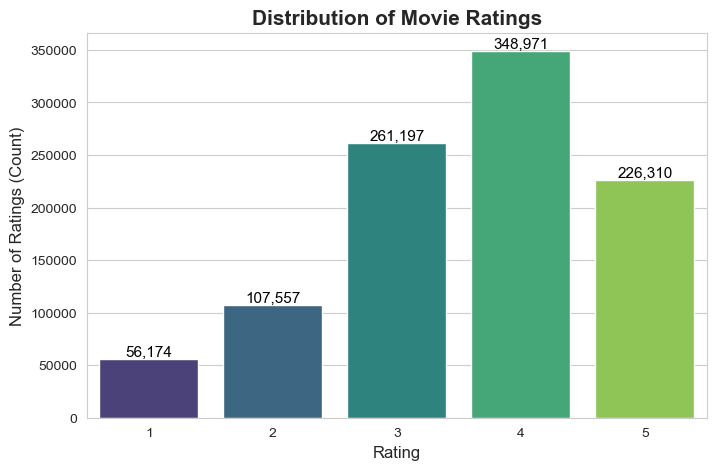

Average rating: 3.58
Median rating: 4.0

--- 2. Analyzing Ratings per Movie ---


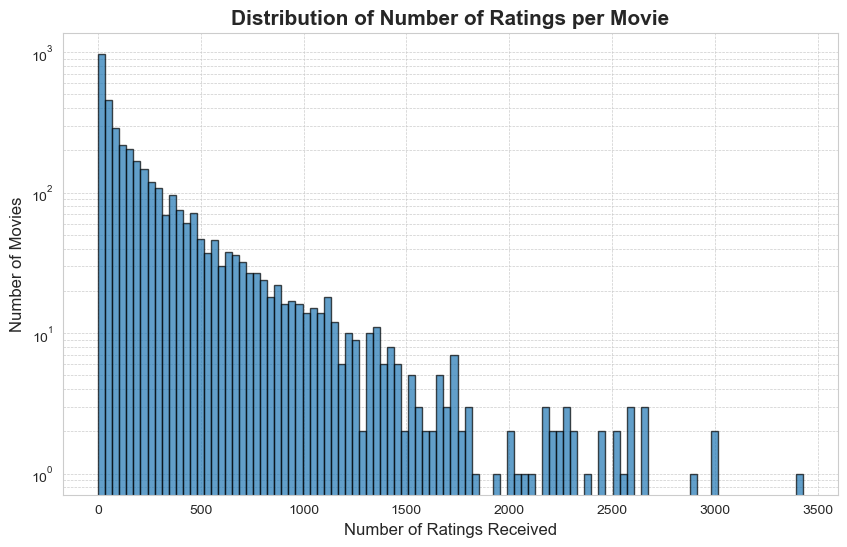

Average number of ratings per movie: 269.89
Median number of ratings per movie: 124

Top 10 Most Rated Movies:
                                                  Title  count  \
2651                             American Beauty (1999)   3428   
253           Star Wars: Episode IV - A New Hope (1977)   2991   
1106  Star Wars: Episode V - The Empire Strikes Back...   2990   
1120  Star Wars: Episode VI - Return of the Jedi (1983)   2883   
466                                Jurassic Park (1993)   2672   
1848                         Saving Private Ryan (1998)   2653   
575                   Terminator 2: Judgment Day (1991)   2649   
2374                                 Matrix, The (1999)   2590   
1178                          Back to the Future (1985)   2583   
579                    Silence of the Lambs, The (1991)   2578   

                                   Genres  
2651                         Comedy|Drama  
253       Action|Adventure|Fantasy|Sci-Fi  
1106    Action|Adventure|Drama

In [8]:
"""
Part 2: Exploratory Data Analysis (EDA)
"""

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size

# --- 1. Overall Rating Distribution ---
print("\n--- 1. Analyzing Rating Distribution ---")
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=ratings, palette='viridis')
plt.title('Distribution of Movie Ratings', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Ratings (Count)', fontsize=12)
# Add text labels
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

print(f"Average rating: {ratings['Rating'].mean():.2f}")
print(f"Median rating: {ratings['Rating'].median()}")


# --- 2. Number of Ratings per Movie ---
print("\n--- 2. Analyzing Ratings per Movie ---")
ratings_per_movie = ratings.groupby('MovieID').size()

plt.figure(figsize=(10, 6))
plt.hist(ratings_per_movie, bins=100, edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Ratings per Movie', fontsize=15, fontweight='bold')
plt.xlabel('Number of Ratings Received', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.yscale('log') # Use log scale due to high skewness
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print(f"Average number of ratings per movie: {ratings_per_movie.mean():.2f}")
print(f"Median number of ratings per movie: {ratings_per_movie.median():.0f}")
print("\nTop 10 Most Rated Movies:")
# Merge with movies DataFrame to get titles
most_rated_movies = pd.DataFrame({'count': ratings_per_movie}).merge(movies, on='MovieID')
print(most_rated_movies.sort_values('count', ascending=False).head(10)[['Title', 'count', 'Genres']])

1.  **Rating Distribution (Plot & Stats):**
    *   The bar chart shows the frequency of each rating score (1-5).
    *   Ratings are clearly skewed towards the higher end, with 4 being the most frequent rating, followed closely by 5 and then 3. Ratings of 1 and 2 are much less common.
    *   This indicates a generally positive bias in the ratings provided within this dataset.
    *   The average rating is ~3.58, while the median rating is 4.0, further confirming the skew towards higher ratings.

2.  **Ratings per Movie (Plot & Stats):**
    *   The histogram displays the distribution of how many ratings each movie received. A logarithmic scale is used for the y-axis (Number of Movies) because the distribution is highly skewed (a "long tail").
    *   A vast majority of movies received relatively few ratings (e.g., less than a few hundred), while a small number of movies received thousands of ratings. This is typical - popular blockbusters get rated much more often than niche films.
    *   The statistics show a mean of 270 ratings per movie, but the median is only 124, highlighting the influence of the highly-rated movies on the mean. The standard deviation is large (383), indicating wide variability. The minimum number of ratings for a movie in the dataset is 1, while the maximum is 3428 (for American Beauty).
    *   The list of the Top 10 most rated movies confirms this, featuring well-known and often critically acclaimed blockbusters from the relevant era (e.g., Star Wars films, Jurassic Park, The Matrix, American Beauty).


--- 3. Analyzing Ratings per User ---


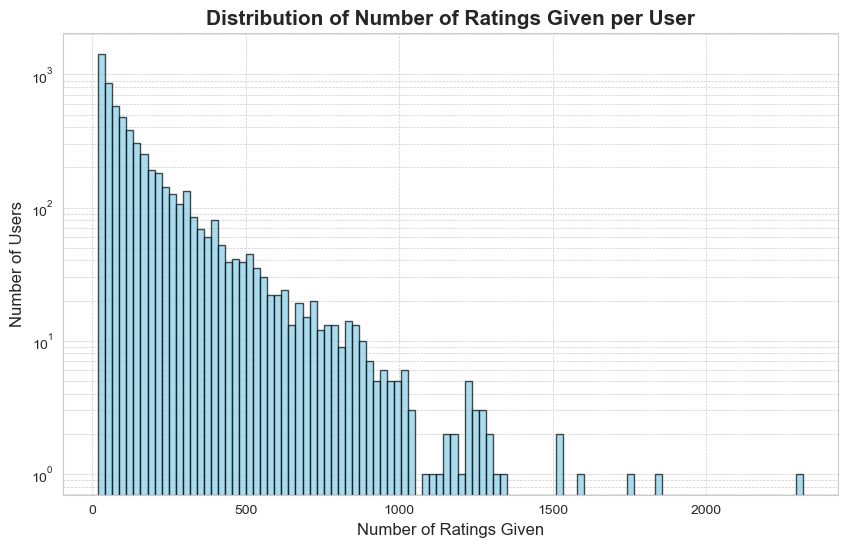

Average number of ratings per user: 165.60
Median number of ratings per user: 96
Minimum ratings per user (as per dataset description): 20

Top 10 Most Active Users (by rating count):
UserID
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
dtype: int64

--- 4. Analyzing Average Movie Ratings ---


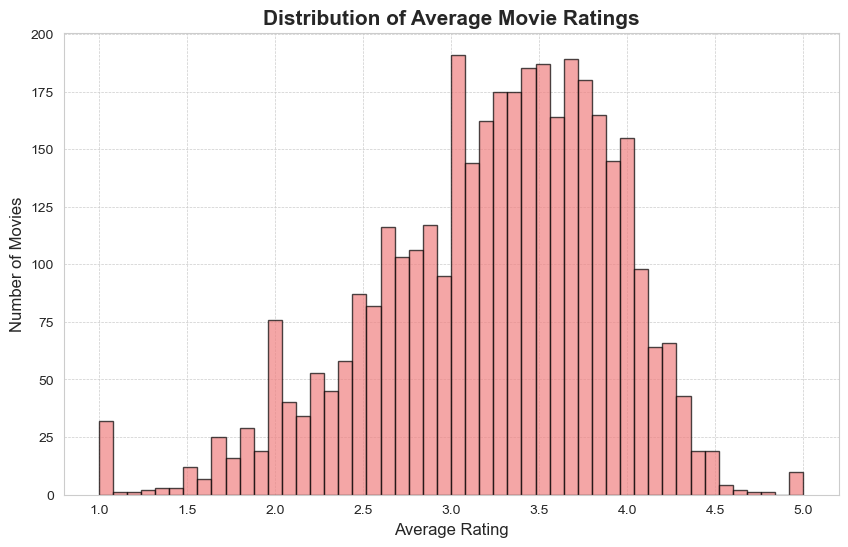


Top 10 Highest Rated Movies (with at least 50 ratings):
                                                  Title  avg_rating  \
2698                                     Sanjuro (1962)    4.608696   
1839  Seven Samurai (The Magnificent Seven) (Shichin...    4.560510   
309                    Shawshank Redemption, The (1994)    4.554558   
802                               Godfather, The (1972)    4.524966   
708                               Close Shave, A (1995)    4.520548   
49                           Usual Suspects, The (1995)    4.517106   
513                             Schindler's List (1993)    4.510417   
1066                         Wrong Trousers, The (1993)    4.507937   
861       Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)    4.491489   
1108                     Raiders of the Lost Ark (1981)    4.477725   

      num_ratings                     Genres  
2698           69           Action|Adventure  
1839          628               Action|Drama  
309          2227   

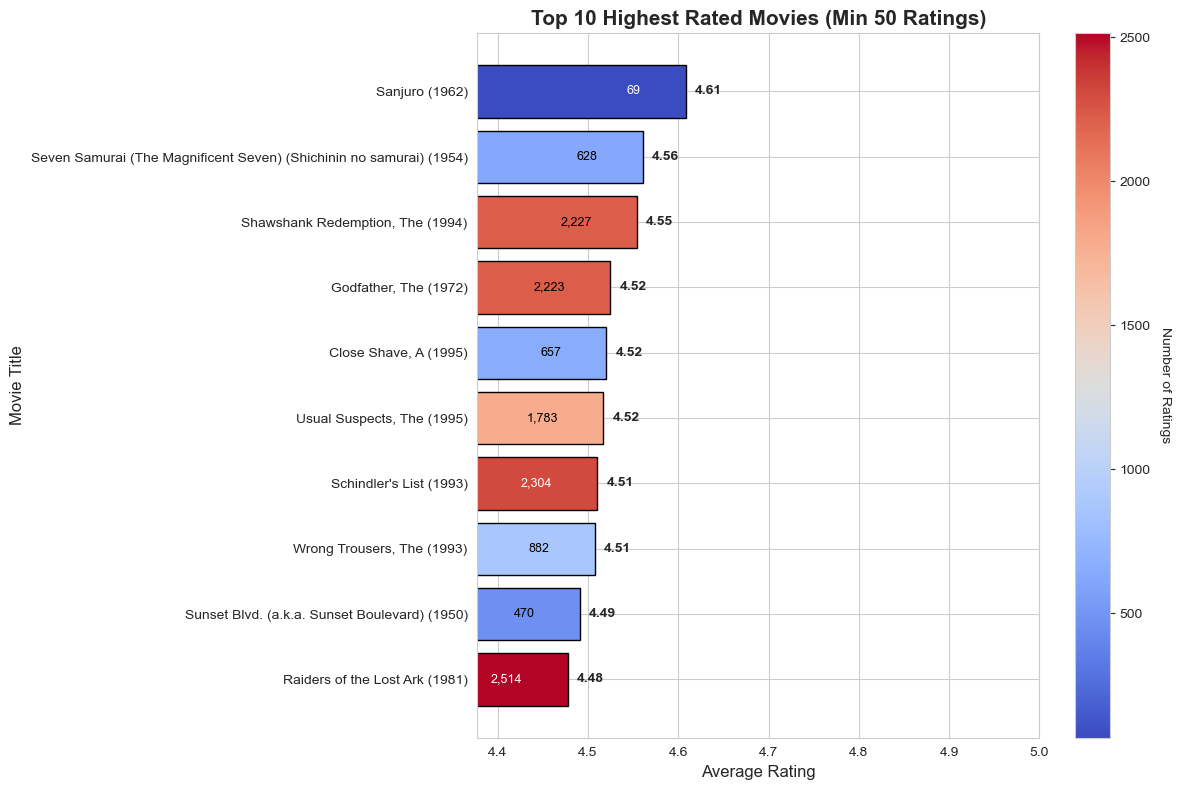

In [10]:
# --- 3. Number of Ratings per User ---
print("\n--- 3. Analyzing Ratings per User ---")
ratings_per_user = ratings.groupby('UserID').size()

plt.figure(figsize=(10, 6))
plt.hist(ratings_per_user, bins=100, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Number of Ratings Given per User', fontsize=15, fontweight='bold')
plt.xlabel('Number of Ratings Given', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.yscale('log') # Use log scale
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print(f"Average number of ratings per user: {ratings_per_user.mean():.2f}")
print(f"Median number of ratings per user: {ratings_per_user.median():.0f}")
print(f"Minimum ratings per user (as per dataset description): {ratings_per_user.min()}")
print("\nTop 10 Most Active Users (by rating count):")
print(ratings_per_user.sort_values(ascending=False).head(10))


# --- 4. Average Movie Ratings (Considering Rating Count) ---
print("\n--- 4. Analyzing Average Movie Ratings ---")
# Calculate average rating and count per movie
movie_stats = ratings.groupby('MovieID').agg(
    num_ratings=('Rating', 'size'),
    avg_rating=('Rating', 'mean')
).reset_index()

# Merge with movie titles
movie_stats = movie_stats.merge(movies, on='MovieID')

# Distribution of average ratings
plt.figure(figsize=(10, 6))
plt.hist(movie_stats['avg_rating'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
plt.title('Distribution of Average Movie Ratings', fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

# Top 10 movies by average rating, requires minimum number of ratings
min_ratings_threshold = 50 # Set a threshold to avoid movies with few ratings dominating
print(f"\nTop 10 Highest Rated Movies (with at least {min_ratings_threshold} ratings):")
top_rated = movie_stats[movie_stats['num_ratings'] >= min_ratings_threshold] \
    .sort_values('avg_rating', ascending=False) \
    .head(10)
print(top_rated[['Title', 'avg_rating', 'num_ratings', 'Genres']])

# Plot top 10 highest rated
plt.figure(figsize=(12, 8))
# Create a color palette based on number of ratings
# Check if top_rated is not empty before calculating min/max
if not top_rated.empty:
    norm = plt.Normalize(top_rated['num_ratings'].min(), top_rated['num_ratings'].max())
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    colors = cmap(norm(top_rated['num_ratings']))
else:
    # Handle empty DataFrame case (e.g., if threshold is too high)
    print(f"Warning: No movies found with at least {min_ratings_threshold} ratings.")
    colors = 'blue' # Default color if no data
    norm = None
    cmap = None


bars = plt.barh(top_rated['Title'], top_rated['avg_rating'], color=colors, edgecolor='black')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.title(f'Top 10 Highest Rated Movies (Min {min_ratings_threshold} Ratings)', fontsize=15, fontweight='bold')

if not top_rated.empty:
    plt.xlim(top_rated['avg_rating'].min() - 0.1, 5.0) # Adjust x-limit for better view
else:
    plt.xlim(0, 5.0) # Default limits if no data

# Add rating labels (outside the bar)
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{top_rated["avg_rating"].iloc[i]:.2f}',
             va='center', ha='left', fontsize=10, fontweight='bold')

# Add number of ratings labels (inside the bar, simplified format)
for i, bar in enumerate(bars):
     # Determine text color based on background bar color brightness
     text_color = 'white'
     if norm: # Check if normalization was possible (i.e., data exists)
         try:
             # Get the color value and check brightness (simple heuristic)
             bar_color_rgba = cmap(norm(top_rated["num_ratings"].iloc[i]))
             # Calculate perceived luminance
             luminance = 0.299 * bar_color_rgba[0] + 0.587 * bar_color_rgba[1] + 0.114 * bar_color_rgba[2]
             if luminance > 0.5: # If background is light, use black text
                 text_color = 'black'
         except IndexError:
             text_color = 'black' # Fallback
     else:
        text_color = 'black' # Default if no norm/cmap

     plt.text(bar.get_width() - 0.05 , bar.get_y() + bar.get_height()/2, # Position inside the bar
              f'{top_rated["num_ratings"].iloc[i]:,}', 
              va='center', ha='right', fontsize=9, color=text_color, fontweight='medium') # Use medium weight

# Color bar legend
if cmap and norm and not top_rated.empty:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_label('Number of Ratings', rotation=270, labelpad=15)

plt.gca().invert_yaxis() # Show highest rated on top
plt.tight_layout()
plt.show()

3.  **Ratings per User (Plot & Stats):**
    *   Similar to the ratings per movie, this distribution is highly skewed (long tail), shown clearly by the log scale on the y-axis (Number of Users).
    *   Most users have rated a relatively small number of movies (median is 96), while a few users are extremely active, rating over 1000 or even 2000 movies.
    *   The minimum number of ratings per user is 20, confirming the dataset's selection criteria mentioned in the README. The average user rated ~166 movies. This confirms sufficient data per user for collaborative filtering.

4.  **Average Movie Ratings (Plots & Stats):**
    *   The first histogram shows the distribution of the average rating calculated for *all* movies (including those with few ratings). It appears roughly normally distributed but centered slightly above 3.0 (mean ~3.2).
    *   The second plot shows the Top 10 highest-rated movies *after filtering* for movies with at least 50 ratings. This provides a more reliable view of well-regarded films.
    *   The top list consists of critically acclaimed classics (e.g., Seven Samurai, Shawshank Redemption, The Godfather, Schindler's List) and some highly-rated niche or animated films (e.g., Sanjuro, Close Shave). The average ratings are very high (mostly > 4.4).
    *   The color bar effectively shows that some top-rated movies have many ratings (like Shawshank, Godfather, Raiders) while others achieved high scores with fewer, though still significant, ratings (like Sanjuro).

Genre Popularity (Number of Movies per Genre):
GenreList
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64


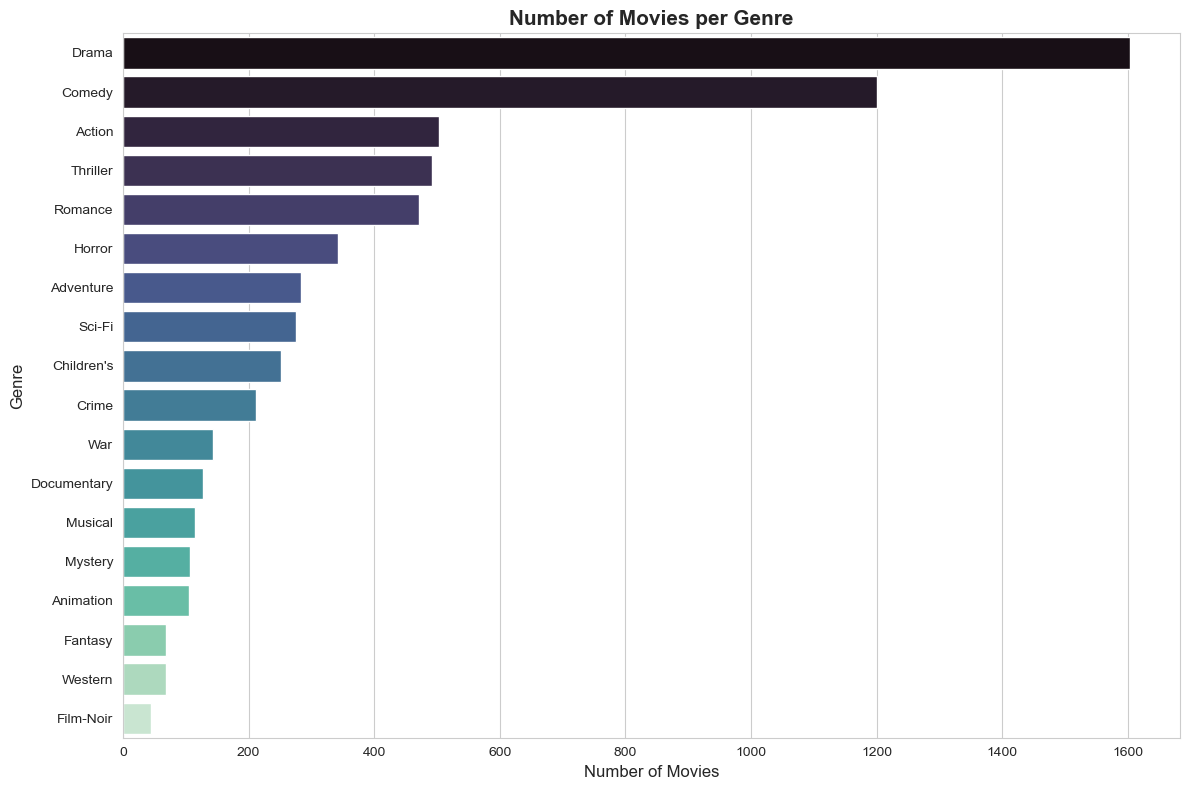


Average Rating and Number of Ratings per Genre:
      GenreList  num_ratings  avg_rating
9     Film-Noir        18261    4.075188
6   Documentary         7910    3.933123
16          War        68527    3.893327
7         Drama       354529    3.766332
5         Crime        79541    3.708679
2     Animation        43293    3.684868
12      Mystery        40178    3.668102
11      Musical        41533    3.665519
17      Western        20683    3.637770
13      Romance       147523    3.607465
15     Thriller       189680    3.570466
4        Comedy       356580    3.522099
0        Action       257457    3.491185
1     Adventure       133953    3.477257
14       Sci-Fi       157294    3.466521
8       Fantasy        36301    3.447371
3    Children's        72186    3.422035
10       Horror        76386    3.215013


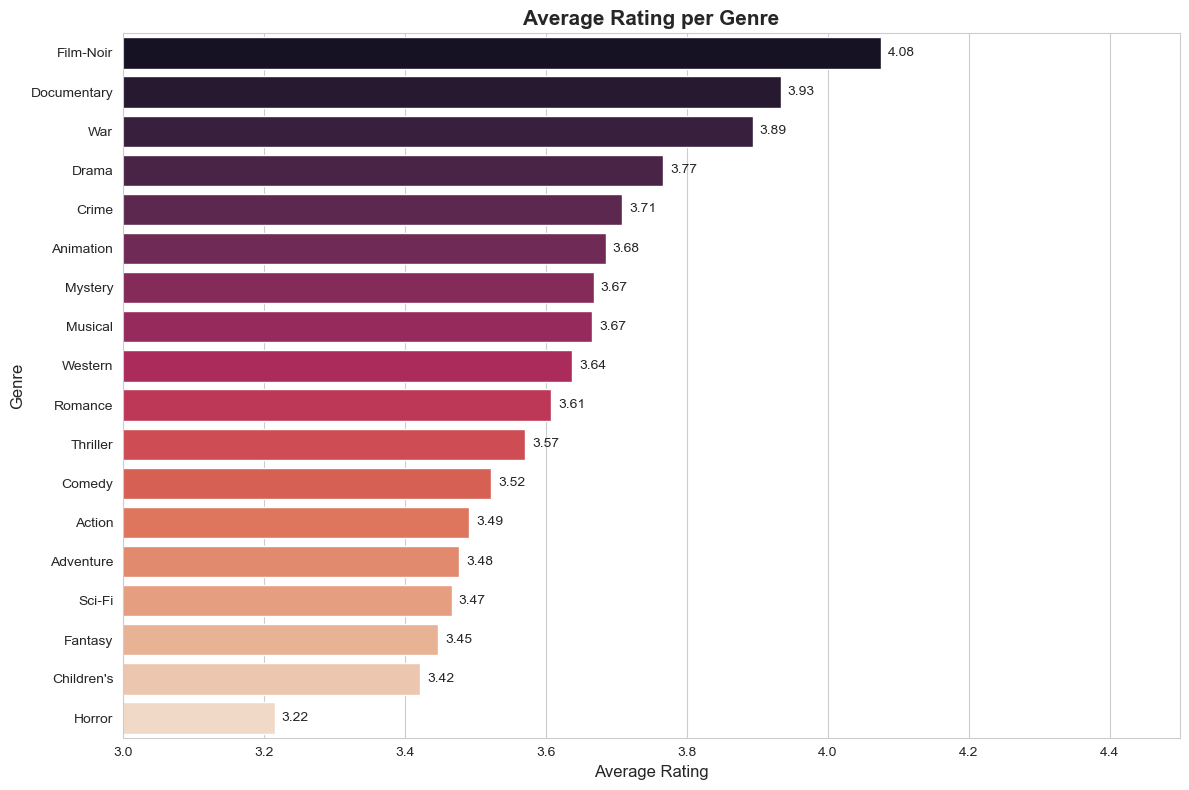


--- 6. Analyzing User Demographics ---


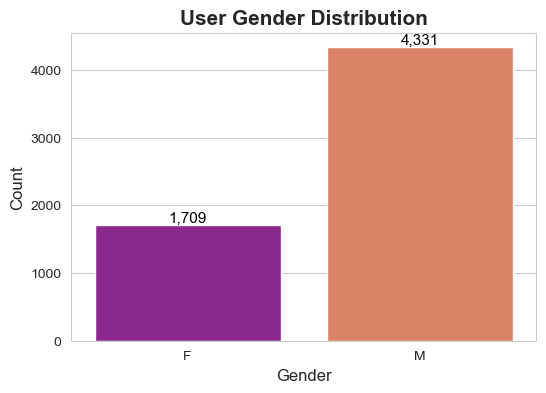

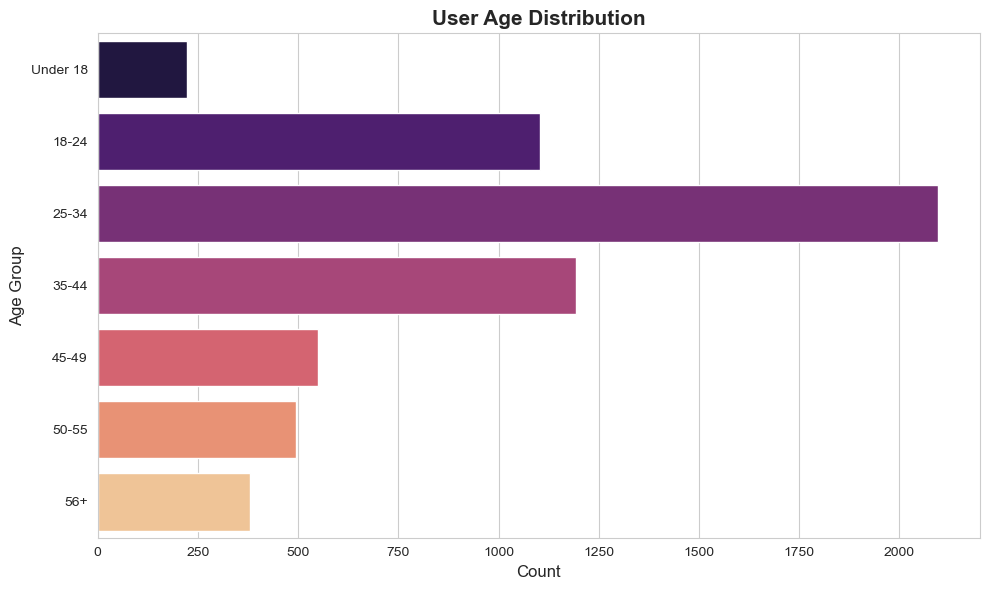

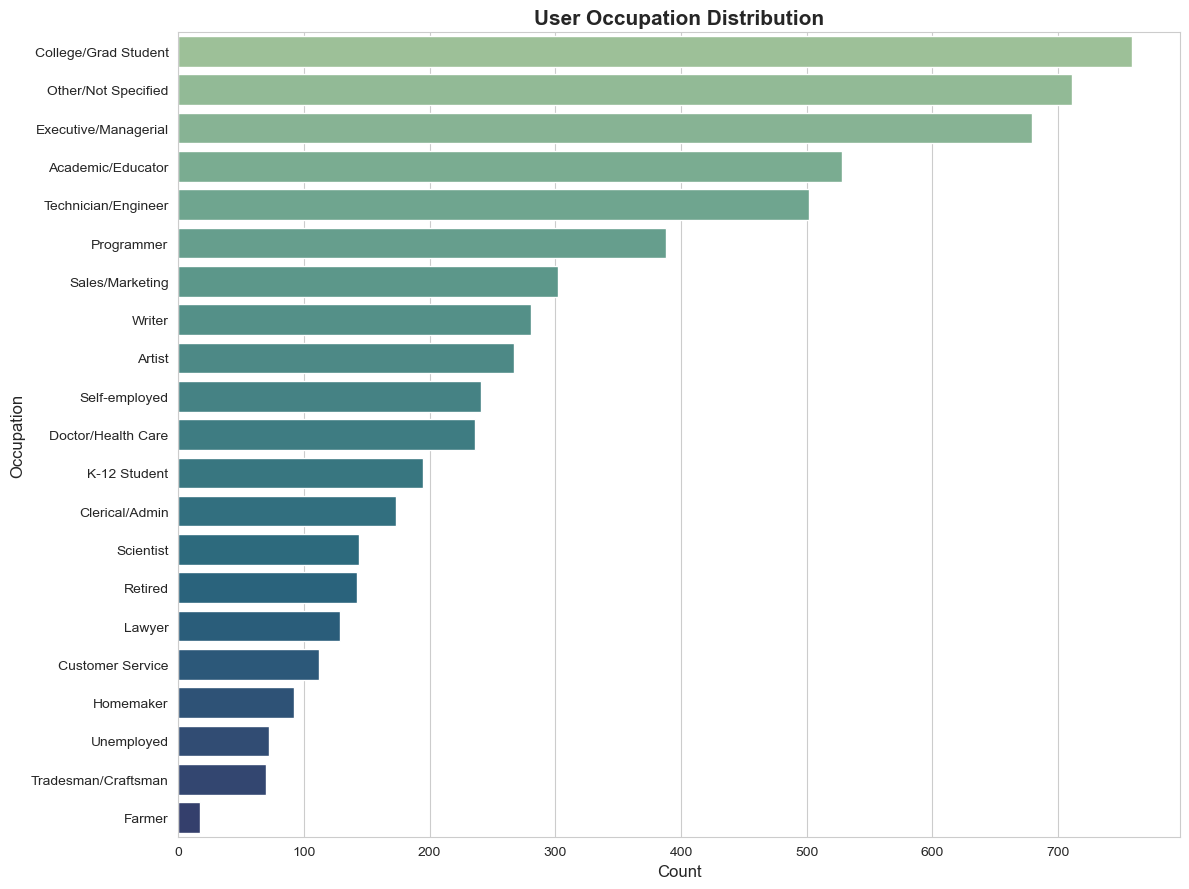


Average Rating by Gender:
  Gender    Rating
0      F  3.620366
1      M  3.568879


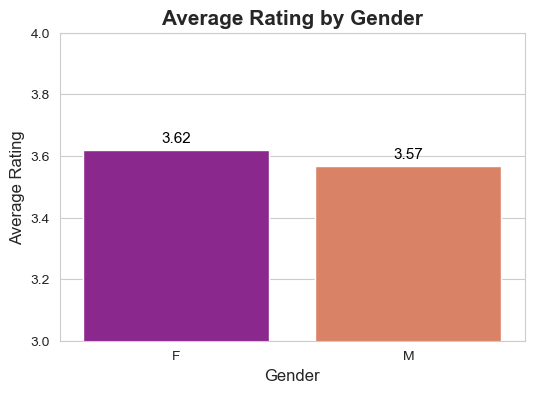


Average Rating by Age Group:
   AgeGroup      mean    size
0     18-24  3.507573  183536
1     25-34  3.545235  395556
2     35-44  3.618162  199003
3     45-49  3.638062   83633
4     50-55  3.714512   72490
5       56+  3.766632   38780
6  Under 18  3.549520   27211


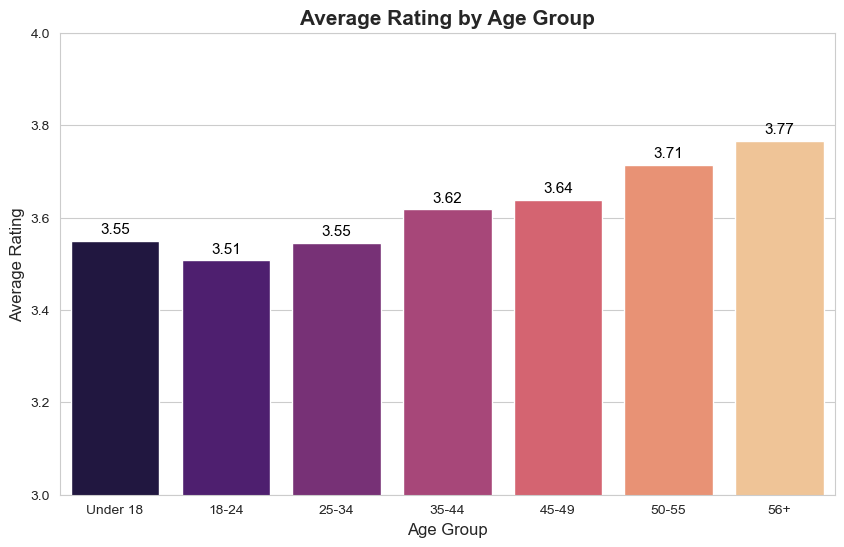

In [12]:
# --- 5. Genre Analysis ---

# Create a DataFrame with each movie-genre pair
# 1. Split the 'Genres' string into a list of genres
movies['GenreList'] = movies['Genres'].str.split('|')
# 2. Explode the DataFrame to have one row per genre for each movie
movies_exploded = movies.explode('GenreList')

# Count occurrences of each genre
genre_counts = movies_exploded['GenreList'].value_counts()

print("Genre Popularity (Number of Movies per Genre):")
print(genre_counts)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='mako', orient='h')
plt.title('Number of Movies per Genre', fontsize=15, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

# Average rating per genre
# Merge ratings with the exploded genre table
ratings_with_genre = ratings.merge(movies_exploded[['MovieID', 'GenreList']], on='MovieID')
genre_stats = ratings_with_genre.groupby('GenreList').agg(
    num_ratings=('Rating', 'size'),
    avg_rating=('Rating', 'mean')
).reset_index().sort_values('avg_rating', ascending=False)

print("\nAverage Rating and Number of Ratings per Genre:")
print(genre_stats)

plt.figure(figsize=(12, 8))
sns.barplot(x='avg_rating', y='GenreList', data=genre_stats, palette='rocket', orient='h')
plt.title('Average Rating per Genre', fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(3.0, 4.5) # Adjust limits based on typical rating range
# Add labels for average rating
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height() / 2,
             f'{width:.2f}',
             va='center', ha='left', fontsize=10)
plt.tight_layout()
plt.show()


# --- 6. User Demographics Analysis ---
print("\n--- 6. Analyzing User Demographics ---")

# Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=users, palette='plasma')
plt.title('User Gender Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Age Distribution - Map age codes to readable labels
age_map = { 1: 'Under 18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
users['AgeGroup'] = users['Age'].map(age_map)

plt.figure(figsize=(10, 6))
sns.countplot(y='AgeGroup', data=users, palette='magma', order=age_map.values())
plt.title('User Age Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.tight_layout()
plt.show()

# Occupation Distribution - Map codes to labels
occupation_map = { 0: 'Other/Not Specified', 1: 'Academic/Educator', 2: 'Artist', 3: 'Clerical/Admin',
                   4: 'College/Grad Student', 5: 'Customer Service', 6: 'Doctor/Health Care',
                   7: 'Executive/Managerial', 8: 'Farmer', 9: 'Homemaker', 10: 'K-12 Student',
                   11: 'Lawyer', 12: 'Programmer', 13: 'Retired', 14: 'Sales/Marketing',
                   15: 'Scientist', 16: 'Self-employed', 17: 'Technician/Engineer',
                   18: 'Tradesman/Craftsman', 19: 'Unemployed', 20: 'Writer' }
users['OccupationDesc'] = users['Occupation'].map(occupation_map)

plt.figure(figsize=(12, 9))
sns.countplot(y='OccupationDesc', data=users, palette='crest', order=users['OccupationDesc'].value_counts().index)
plt.title('User Occupation Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Occupation', fontsize=12)
plt.tight_layout()
plt.show()

# Merge ratings with user demographics for comparison
ratings_users = ratings.merge(users, on='UserID')

# Average rating by Gender
avg_rating_gender = ratings_users.groupby('Gender')['Rating'].mean().reset_index()
print("\nAverage Rating by Gender:")
print(avg_rating_gender)

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Rating', data=avg_rating_gender, palette='plasma')
plt.title('Average Rating by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.0, 4.0) # Set ylim for better comparison
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 3),
                textcoords='offset points')
plt.show()


# Average rating by Age Group
avg_rating_age = ratings_users.groupby('AgeGroup')['Rating'].agg(['mean', 'size']).reset_index()
print("\nAverage Rating by Age Group:")
print(avg_rating_age)

plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='mean', data=avg_rating_age, palette='magma', order=age_map.values())
plt.title('Average Rating by Age Group', fontsize=15, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.0, 4.0) # Set ylim for better comparison
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 3),
                textcoords='offset points')
plt.show()

5.  **Genre Analysis (Plots & Stats):**
    *   **Popularity:** The first bar chart shows Drama and Comedy are by far the most numerous genres in the dataset, followed by Action, Thriller, and Romance. Genres like Film-Noir, Western, and Fantasy are much less represented.
    *   **Average Rating:** The second bar chart reveals interesting patterns. Genres often associated with critical acclaim like Film-Noir, Documentary, and War have the highest average ratings (around 3.9-4.1). Mainstream genres like Action, Comedy, and Sci-Fi have average ratings closer to the overall dataset mean (3.5). Horror has the lowest average rating (3.2). This suggests genre preference influences average perceived quality.

6.  **User Demographics (Plots & Stats):**
    *   **Gender:** The dataset is predominantly male (72% M vs 28% F). Females tend to give slightly higher ratings on average (3.62) than males (3.57), although the difference is small.
    *   **Age:** The largest user group is 25-34, followed by 18-24 and 35-44. There are fewer users in the youngest ('Under 18') and oldest ('56+') categories. Average ratings show a slight upward trend with age, with the '56+' group giving the highest average ratings (3.77) and the '18-24' group giving the lowest (3.51).
    *   **Occupation:** College/grad students, 'Other/Not specified', and Executive/Managerial are the most common occupations. Farmers, unemployed, and tradesmen are the least common. (Average ratings per occupation could be explored but might become too granular).


--- 7. Analyzing Rating Trends Over Time ---

Ratings Statistics per Year:
      num_ratings  avg_rating
Year                         
2000       904757    3.590392
2001        68058    3.512254
2002        24046    3.458829
2003         3348    3.486559


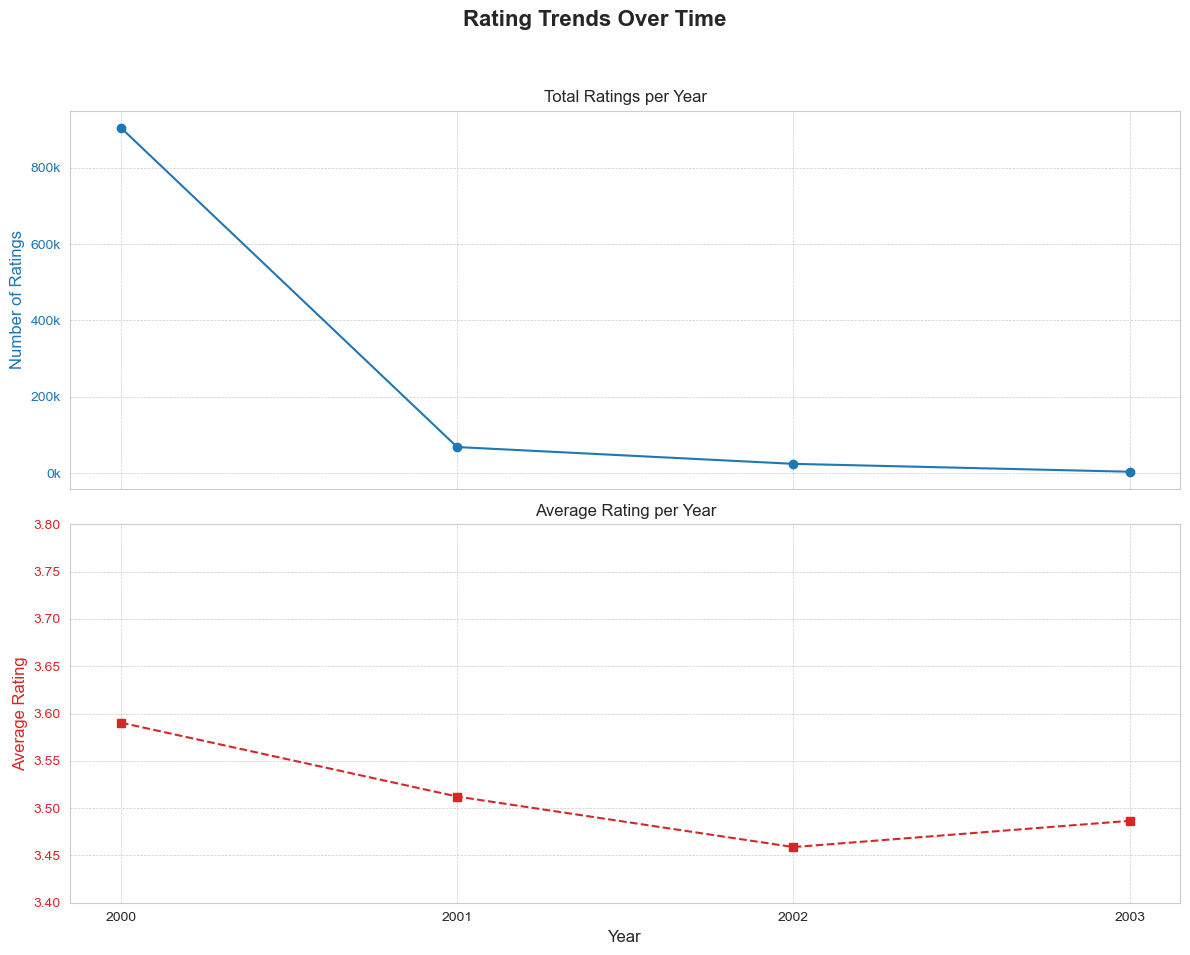

In [14]:
# --- 7. Temporal Analysis ---
print("\n--- 7. Analyzing Rating Trends Over Time ---")

# Extract year from Timestamp
ratings['Year'] = ratings['Timestamp'].dt.year

# Ratings per year
ratings_per_year = ratings.groupby('Year').size()

# Average rating per year
avg_rating_per_year = ratings.groupby('Year')['Rating'].mean()

# Combine into one DataFrame
temporal_stats = pd.DataFrame({'num_ratings': ratings_per_year, 'avg_rating': avg_rating_per_year})

print("\nRatings Statistics per Year:")
print(temporal_stats)

# Create figure with two subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Rating Trends Over Time', fontsize=16, fontweight='bold')

# Plot 1: Number of ratings per year
ax1.plot(temporal_stats.index, temporal_stats['num_ratings'], marker='o', linestyle='-', color='tab:blue')
ax1.set_ylabel('Number of Ratings', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Total Ratings per Year')
ax1.grid(True, linestyle='--', linewidth=0.5)
# Format y-axis
from matplotlib.ticker import FuncFormatter
def format_k(value, tick_number):
    return f'{value / 1000:,.0f}k'
ax1.yaxis.set_major_formatter(FuncFormatter(format_k))


# Plot 2: Average rating per year
ax2.plot(temporal_stats.index, temporal_stats['avg_rating'], marker='s', linestyle='--', color='tab:red')
ax2.set_ylabel('Average Rating', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_title('Average Rating per Year')
ax2.grid(True, linestyle='--', linewidth=0.5)
ax2.set_ylim(3.4, 3.8) # Focus the y-axis range

# Set x-axis ticks to be integers (years)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

7.  **Temporal Analysis (Plot & Stats):**
    *   **Activity:** The plot shows a massive peak in rating activity in the year 2000, dropping sharply afterward. This is because the dataset description states users were selected *who joined MovieLens in 2000*. Most ratings occurred shortly after joining. Activity in 2001-2003 represents ratings from those same users later on.
    *   **Average Rating Trend:** The average rating given per year shows a slight decrease from 2000 (3.59) to 2002 (3.46), followed by a small uptick in 2003 (3.49). The limited data points after 2000 make it hard to draw strong conclusions about long-term trends for this specific user cohort.

# Create mappings for user and movie IDs to contiguous indices and understand the dimensions and sparsity of the potential user-item matrix. This prepares the ground for building matrices within cross-validation folds.

In [17]:
"""
Part 3: Data Preparation for KNN Model
"""

from scipy.sparse import csr_matrix

# Create contiguous user indices (0 to num_users-1)
user_ids = ratings['UserID'].unique()
user_id_map = {id: i for i, id in enumerate(user_ids)}
n_users = len(user_ids)
print(f"Number of unique users (n_users): {n_users}")

# Create contiguous movie indices (0 to num_movies-1) based on *all* rated movies
movie_ids_rated = ratings['MovieID'].unique()
movie_id_map = {id: i for i, id in enumerate(movie_ids_rated)}
movie_idx_to_id_map = {i: id for id, i in movie_id_map.items()} # Reverse map
n_movies = len(movie_ids_rated)
print(f"Number of unique movies rated (n_movies): {n_movies}")

# Add mapped indices to the main ratings DataFrame (useful for splitting later)
if 'UserIndex' not in ratings.columns:
    ratings['UserIndex'] = ratings['UserID'].map(user_id_map)
if 'MovieIndex' not in ratings.columns:
    ratings['MovieIndex'] = ratings['MovieID'].map(movie_id_map)

print("\nRatings DataFrame now includes 'UserIndex' and 'MovieIndex':")
print(ratings.head())

# Calculate overall sparsity (using full dataset dimensions)
num_total_ratings = len(ratings)
matrix_size_total = n_users * n_movies
sparsity_total = 1.0 - (num_total_ratings / matrix_size_total)
print(f"\nOverall Matrix Properties (Full Dataset):")
print(f" - Total ratings: {num_total_ratings}")
print(f" - Full matrix size (users x movies): {matrix_size_total}")
print(f" - Overall sparsity: {sparsity_total:.4f} ({sparsity_total*100:.2f}%)")

Number of unique users (n_users): 6040
Number of unique movies rated (n_movies): 3706

Ratings DataFrame now includes 'UserIndex' and 'MovieIndex':
   UserID  MovieID  Rating           Timestamp  Year  UserIndex  MovieIndex
0       1     1193       5 2000-12-31 22:12:40  2000          0           0
1       1      661       3 2000-12-31 22:35:09  2000          0           1
2       1      914       3 2000-12-31 22:32:48  2000          0           2
3       1     3408       4 2000-12-31 22:04:35  2000          0           3
4       1     2355       5 2001-01-06 23:38:11  2001          0           4

Overall Matrix Properties (Full Dataset):
 - Total ratings: 1000209
 - Full matrix size (users x movies): 22384240
 - Overall sparsity: 0.9553 (95.53%)


-   We confirmed there are 6,040 unique users and 3,706 unique movies that received at least one rating.
-   Mappings (`user_id_map`, `movie_id_map`, `movie_idx_to_id_map`) were created to translate between original IDs and zero-based indices needed for matrix operations. These mappings were added to the main `ratings` DataFrame.
-   The overall potential user-item matrix has dimensions 6040 x 3706 and is extremely sparse (>95%), confirming the need for sparse matrix representations.
-   Crucially, the full sparse matrices are *not* built at this stage; they will be constructed using only the *training* data within each fold of the upcoming cross-validation process.

# Define the K-Nearest Neighbors model configuration and helper functions (like finding similar movies) that will be used later, after the model is trained either within cross-validation or on the full training set.

In [20]:
"""
Part 4: Building and Training the KNN Model
"""

import time
from sklearn.neighbors import NearestNeighbors

# --- KNN Model Configuration ---
# Define parameters that might be tuned or used consistently
METRIC = 'cosine'
ALGORITHM = 'brute'
# K_similarity is for item-item lookup (used later in recommendations/visualization)
K_similarity = 11 # Find 10 nearest neighbors + the item itself for similarity checks

print(f"Default Metric: {METRIC}")
print(f"Default Algorithm: {ALGORITHM}")
print(f"K for item similarity lookup: {K_similarity}")

# Note: The actual KNN model instance for prediction will be created and trained
# within the cross-validation loop (Part 5/6) and potentially retrained finally (Part 7).

# --- Helper Function: Find Similar Movies (using a *trained* model) ---
# This function needs a trained KNN model and associated data structures.
# We define it here but will call it *after* training the final model.

# Recreate title_to_idx mapping if needed (using full movies dataset and movie_id_map)
if 'title_to_idx' not in globals():
    print("Recreating title_to_idx mapping...")
    movie_titles_vis = movies[['MovieID', 'Title']].copy()
    # Ensure mapping only includes movies present in the ratings data (i.e., in movie_id_map)
    movie_titles_vis = movie_titles_vis[movie_titles_vis['MovieID'].isin(movie_id_map)]
    if not movie_titles_vis.empty:
        movie_titles_vis['MovieIndex'] = movie_titles_vis['MovieID'].map(movie_id_map)
        # Handle potential duplicate titles robustly (keep first index)
        title_to_idx = pd.Series(movie_titles_vis.MovieIndex.values, index=movie_titles_vis.Title)
        title_to_idx = title_to_idx[~title_to_idx.index.duplicated(keep='first')].to_dict()
        print("title_to_idx mapping created.")
    else:
        print("Warning: Could not create title_to_idx mapping.")
        title_to_idx = {}

def find_similar_movies(movie_title, model_knn, data_matrix, num_recommendations=10):
    """
    Finds movies similar to a given movie title using a trained KNN model.

    Args:
        movie_title (str): The title of the movie.
        model_knn (NearestNeighbors): The trained KNN model instance.
        data_matrix (csr_matrix): The movie-user sparse matrix the model was trained on.
        num_recommendations (int): Number of similar movies to return.

    Returns:
        pandas.DataFrame or None: DataFrame of similar movies or None if not found.
    """
    print(f"\nFinding movies similar to: '{movie_title}'")
    if not title_to_idx or movie_title not in title_to_idx:
        print(f"Error: Movie '{movie_title}' not found in title map.")
        # Suggest close matches
        try:
            import difflib
            possible_matches = difflib.get_close_matches(movie_title, title_to_idx.keys(), n=5)
            if possible_matches: print(f"Did you mean one of these?\n - " + "\n - ".join(possible_matches))
        except ImportError: pass
        return None

    movie_idx = title_to_idx[movie_title]
    if movie_idx >= data_matrix.shape[0]:
         print(f"Error: Movie index {movie_idx} out of bounds for data matrix shape {data_matrix.shape}.")
         return None

    query_vector = data_matrix[movie_idx]
    distances, indices = model_knn.kneighbors(query_vector, n_neighbors=num_recommendations + 1)

    results = []
    print(f"\nFound {len(indices.flatten()) -1} potential neighbors:")
    for i in range(1, len(distances.flatten())): # Start from 1 to exclude self
        idx = indices.flatten()[i]
        dist = distances.flatten()[i]
        sim = 1.0 - dist
        if sim > 1e-6: # Only include positive similarity
            original_movie_id = movie_idx_to_id_map.get(idx) # Use .get for safety
            if original_movie_id:
                # Safely get title, handle if MovieID somehow missing from 'movies' df
                title_series = movies.loc[movies['MovieID'] == original_movie_id, 'Title']
                title = title_series.iloc[0] if not title_series.empty else f"Unknown Title (ID:{original_movie_id})"
                print(f" - {len(results)+1}. {title} (Similarity: {sim:.4f})")
                results.append({'Title': title, 'Similarity': sim, 'MovieID': original_movie_id})

    return pd.DataFrame(results)

Default Metric: cosine
Default Algorithm: brute
K for item similarity lookup: 11
Recreating title_to_idx mapping...
title_to_idx mapping created.


-   No model is trained yet. Training will happen within the cross-validation process to find the best hyperparameters and evaluate performance robustly.
-   The `find_similar_movies` function is prepared. It requires a *trained* model and the corresponding data matrix to work. We will use this function after the final model is trained (post-cross-validation) to demonstrate item-item similarity as part of the results.
-   The `title_to_idx` mapping is recreated here to ensure it's available for the helper function, handling potential duplicate titles.

# Evaluate the KNN model's predictive performance more robustly using K-Fold Cross-Validation. Tune the hyperparameter 'K' (number of neighbors for prediction) to find the value that yields the best average performance (e.g., lowest RMSE) across the folds.


Performing 5-Fold Cross-Validation.
Testing K values for prediction: [15, 20, 25, 30, 35, 40, 50]

--- Processing Fold 1/5 ---
Fold 1: Train size=800167, Validation size=200042
  Testing K=15...
    K=15: RMSE=0.9759, MAE=0.7415 (took 15.84s)
  Testing K=20...
    K=20: RMSE=0.9640, MAE=0.7365 (took 15.54s)
  Testing K=25...
    K=25: RMSE=0.9564, MAE=0.7332 (took 15.61s)
  Testing K=30...
    K=30: RMSE=0.9504, MAE=0.7305 (took 15.88s)
  Testing K=35...
    K=35: RMSE=0.9475, MAE=0.7295 (took 15.86s)
  Testing K=40...
    K=40: RMSE=0.9451, MAE=0.7287 (took 15.95s)
  Testing K=50...
    K=50: RMSE=0.9425, MAE=0.7284 (took 16.12s)
--- Fold 1 completed in 110.91 seconds ---

--- Processing Fold 2/5 ---
Fold 2: Train size=800167, Validation size=200042
  Testing K=15...
    K=15: RMSE=0.9729, MAE=0.7391 (took 15.94s)
  Testing K=20...
    K=20: RMSE=0.9602, MAE=0.7328 (took 15.61s)
  Testing K=25...
    K=25: RMSE=0.9523, MAE=0.7290 (took 15.70s)
  Testing K=30...
    K=30: RMSE=0.9471,

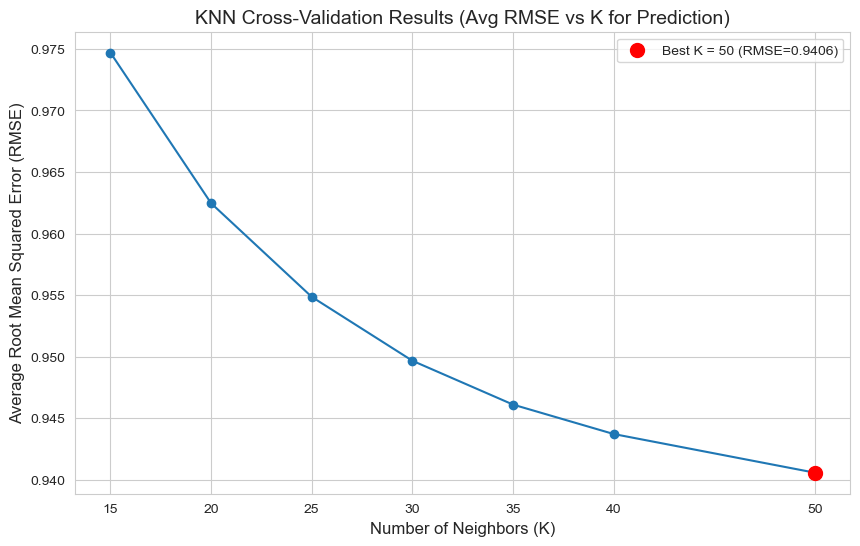


--- Parts 5 & 6: Cross-Validation Finished ---


In [23]:
"""
Part 5 & 6: Cross-Validation, Hyperparameter Tuning & Evaluation
"""

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt # For RMSE calculation
from tqdm.notebook import tqdm # Import tqdm for progress bar
from sklearn.model_selection import train_test_split

# --- CV Configuration ---
N_SPLITS = 5 # Number of folds
RANDOM_STATE_KFOLD = 42 # For reproducible folds
K_VALUES_TO_TEST = [15, 20, 25, 30, 35, 40, 50] # Neighbors for prediction
METRIC = 'cosine'
ALGORITHM = 'brute'

print(f"\nPerforming {N_SPLITS}-Fold Cross-Validation.")
print(f"Testing K values for prediction: {K_VALUES_TO_TEST}")

# Prepare KFold object
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE_KFOLD)

# Dictionary to store results: {k: {'rmse': [fold1_rmse, ...], 'mae': [fold1_mae, ...]}}
cv_results = {k: {'rmse': [], 'mae': []} for k in K_VALUES_TO_TEST}

# --- Cross-Validation Loop ---
fold_counter = 0
# Use ratings DataFrame which now definitely has UserIndex and MovieIndex
for train_idx, val_idx in kf.split(ratings):
    fold_counter += 1
    print(f"\n--- Processing Fold {fold_counter}/{N_SPLITS} ---")
    start_fold_time = time.time()

    # 1. Create train/validation sets for this fold using .iloc
    train_ratings_fold = ratings.iloc[train_idx].copy() # Use .copy() to avoid warnings
    val_ratings_fold = ratings.iloc[val_idx].copy()   # Use .copy()
    print(f"Fold {fold_counter}: Train size={len(train_ratings_fold)}, Validation size={len(val_ratings_fold)}")

    # 2. Calculate user averages ONLY from fold's training data
    user_avg_ratings_fold = train_ratings_fold.groupby('UserIndex')['Rating'].mean()
    user_avg_dict_fold = user_avg_ratings_fold.to_dict()
    global_avg_rating_fold = train_ratings_fold['Rating'].mean()

    # 3. Build sparse matrices ONLY from fold's training data
    # Use dimensions based on the *full* dataset (n_users, n_movies) for consistency
    train_user_item_fold = csr_matrix(
        (train_ratings_fold['Rating'].values, (train_ratings_fold['UserIndex'].values, train_ratings_fold['MovieIndex'].values)),
        shape=(n_users, n_movies)
    )
    train_movie_user_fold = train_user_item_fold.T

    # --- Hyperparameter Tuning Loop (within fold) ---
    for k_pred in K_VALUES_TO_TEST:
        print(f"  Testing K={k_pred}...")
        start_k_time = time.time()

        # 4. Train KNN model for this K
        model_knn_fold = NearestNeighbors(metric=METRIC, algorithm=ALGORITHM, n_neighbors=k_pred + 1, n_jobs=-1)
        model_knn_fold.fit(train_movie_user_fold)

        # 5. Precompute neighbors for validation set movies
        val_movie_indices = val_ratings_fold['MovieIndex'].unique()
        # Ensure indices are within the bounds of the matrix trained in this fold
        valid_val_movie_indices_mask = val_movie_indices < train_movie_user_fold.shape[0]
        val_movie_indices = val_movie_indices[valid_val_movie_indices_mask]
        precomputed_neighbors_fold = {}
        if len(val_movie_indices) > 0:
            query_vectors_fold = train_movie_user_fold[val_movie_indices]
            distances_batch, indices_batch = model_knn_fold.kneighbors(query_vectors_fold, n_neighbors=k_pred + 1)
            for i, movie_idx in enumerate(val_movie_indices):
                neighbor_indices = indices_batch[i, 1:]
                similarities = 1.0 - distances_batch[i, 1:]
                valid_mask = similarities > 1e-6
                precomputed_neighbors_fold[movie_idx] = (neighbor_indices[valid_mask], similarities[valid_mask])

        # 6. Define Prediction Function (specific to this fold's data)
        # Note: Defining the function inside the loop ensures it uses the correct fold-specific data
        # (user_avg_dict_fold, global_avg_rating_fold, precomputed_neighbors_fold, train_user_item_fold)
        def predict_rating_fold_optimized(user_idx, movie_idx):
            user_avg = user_avg_dict_fold.get(user_idx, global_avg_rating_fold)
            default_prediction = user_avg
            if movie_idx not in precomputed_neighbors_fold: return default_prediction
            neighbor_movie_indices, neighbor_similarities = precomputed_neighbors_fold[movie_idx]
            if len(neighbor_movie_indices) == 0: return default_prediction
            try:
                user_ratings_vector = train_user_item_fold[user_idx, :]
                neighbor_ratings = user_ratings_vector[:, neighbor_movie_indices]
                rated_mask = neighbor_ratings.nnz > 0
                if not rated_mask: return default_prediction
                relevant_indices_in_slice = neighbor_ratings.indices
                ratings_data = neighbor_ratings.data
                relevant_similarities = neighbor_similarities[relevant_indices_in_slice]
                sum_of_similarities = relevant_similarities.sum()
                if len(ratings_data) == 0 or sum_of_similarities <= 1e-6: return default_prediction
                weighted_sum = np.dot(ratings_data, relevant_similarities)
                predicted_rating = np.clip(weighted_sum / sum_of_similarities, 1.0, 5.0)
                return predicted_rating
            except Exception: return default_prediction

        # 7. Predict on validation set for this fold and K
        predictions_fold = np.zeros(len(val_ratings_fold))
        val_iter = val_ratings_fold[['UserIndex', 'MovieIndex']].itertuples()
        val_iter_prog = tqdm(val_iter, total=len(val_ratings_fold), desc=f"  Fold {fold_counter} Pred (K={k_pred})", leave=False) if 'tqdm' in globals() and tqdm != globals().get('tqdm') else val_iter

        for i, row in enumerate(val_iter_prog):
             predictions_fold[i] = predict_rating_fold_optimized(int(row.UserIndex), int(row.MovieIndex))

        # Handle potential NaNs
        nan_mask = np.isnan(predictions_fold)
        if np.any(nan_mask):
            predictions_fold[nan_mask] = global_avg_rating_fold

        # 8. Evaluate and store results for this K and fold
        actual_ratings_fold = val_ratings_fold['Rating'].values
        fold_rmse = sqrt(mean_squared_error(actual_ratings_fold, predictions_fold))
        fold_mae = mean_absolute_error(actual_ratings_fold, predictions_fold)
        cv_results[k_pred]['rmse'].append(fold_rmse)
        cv_results[k_pred]['mae'].append(fold_mae)

        print(f"    K={k_pred}: RMSE={fold_rmse:.4f}, MAE={fold_mae:.4f} (took {time.time() - start_k_time:.2f}s)")

    # End of K loop for the fold
    print(f"--- Fold {fold_counter} completed in {time.time() - start_fold_time:.2f} seconds ---")

# --- Analyze CV Results ---
print("\n--- Cross-Validation Results Summary ---")
avg_rmse_results = {}
avg_mae_results = {}
for k in K_VALUES_TO_TEST:
    avg_rmse_results[k] = np.mean(cv_results[k]['rmse'])
    avg_mae_results[k] = np.mean(cv_results[k]['mae'])
    print(f"K = {k:2d} -> Avg RMSE: {avg_rmse_results[k]:.4f}, Avg MAE: {avg_mae_results[k]:.4f}")

# Find the best K based on lowest average RMSE
# Use min() with a key on the results dictionary
best_k = min(avg_rmse_results, key=avg_rmse_results.get)
best_rmse = avg_rmse_results[best_k]
best_mae = avg_mae_results[best_k] # Get corresponding MAE for the best K

print(f"\nBest K value for prediction based on lowest Avg RMSE: {best_k}")
print(f"Corresponding Avg RMSE: {best_rmse:.4f}")
print(f"Corresponding Avg MAE: {best_mae:.4f}")

# Plot CV results (RMSE vs K)
plt.figure(figsize=(10, 6))
# Extract K values and corresponding average RMSEs for plotting
k_vals = list(avg_rmse_results.keys())
rmse_vals = list(avg_rmse_results.values())
plt.plot(k_vals, rmse_vals, marker='o', linestyle='-')
plt.title('KNN Cross-Validation Results (Avg RMSE vs K for Prediction)', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Average Root Mean Squared Error (RMSE)', fontsize=12)
plt.xticks(K_VALUES_TO_TEST) # Ensure all tested K values are marked
plt.grid(True)
# Highlight the best K
plt.scatter(best_k, best_rmse, color='red', s=100, zorder=5, label=f'Best K = {best_k} (RMSE={best_rmse:.4f})')
plt.legend()
plt.show()

print("\n--- Parts 5 & 6: Cross-Validation Finished ---")
# The variable `best_k` now holds the optimal number of neighbors found.

1.  **Process:** A 5-fold cross-validation strategy was employed to get a reliable estimate of the model's performance and to tune the number of neighbors (`K`) used for prediction. The `ratings` data was split into 5 folds, and iteratively, 4 folds were used for training and 1 fold for validation. This process was repeated 5 times, ensuring each data point served as validation data once. Within each fold, the model was trained and evaluated for different values of `K`: 15, 20, 25, 30, 35, 40, and 50.
2.  **Fold Performance:** The output shows the RMSE and MAE results for each value of `K` within each of the 5 folds.
    *   There is some variation in scores across folds for the same `K` (e.g., for K=50, RMSE ranges from 0.9379 to 0.9425), which is expected due to the different subsets of data used for training/validation in each fold. This highlights why cross-validation is valuable over a single train/test split.
    *   The time taken for prediction within each fold for a given K is consistently around 15-16 seconds, showing the efficiency of the optimized prediction logic. The total time per fold (including retraining/precomputation for all K values) is around 111-112 seconds.
3.  **Average Performance & Trend:** The "Cross-Validation Results Summary" section aggregates the performance across the 5 folds for each `K`.
    *   Both Average RMSE and Average MAE consistently decrease as `K` increases from 15 to 50. This suggests that considering more neighbors generally improves prediction accuracy within this tested range.
    *   The rate of improvement diminishes as K gets larger (e.g., the drop in RMSE from K=40 to K=50 is smaller than from K=15 to K=20).
4.  **Best K Selection:** Based on the objective of minimizing the Average RMSE, the optimal value found among the tested options is **`K = 50`**. This value yielded the lowest average RMSE of **0.9406** and a corresponding average MAE of **0.7264**.
5.  **Visualization:** The plot "KNN Cross-Validation Results (Avg RMSE vs K for Prediction)" visually confirms the trend observed in the summary statistics. The blue line shows the decreasing average RMSE as K increases, and the red dot clearly marks K=50 as the point with the lowest average RMSE in the tested range.
6.  **Significance:** The cross-validation process provided strong evidence that using `K=50` neighbors is the best choice for this specific item-based KNN model configuration to optimize for RMSE on this dataset. The resulting average RMSE of ~0.94 represents the most reliable estimate of how this tuned model is expected to perform on unseen data.

# After identifying the best K from cross-validation, perform a single train/test split evaluation using this optimal K. This provides a specific test set with predictions needed for visualization in Part 8.

In [26]:
"""
Step 6.5: Single Evaluation Run with Best K
"""

# --- 6.5.1. Perform Single Train/Test Split ---
# Use the same random_state as CV split for consistency if desired, but not strictly necessary
print("Performing single Train/Test Split...")
train_ratings_eval, test_ratings_eval = train_test_split(
    ratings,
    test_size=0.2, # Or use the same percentage as CV validation sets
    random_state=42 # Match CV random state if desired
)
train_ratings_eval = train_ratings_eval.copy()
test_ratings_eval = test_ratings_eval.copy() # This is the crucial DataFrame for Part 8 plots
print(f"Single Eval: Train size={len(train_ratings_eval)}, Test size={len(test_ratings_eval)}")

# --- 6.5.2. Prepare Data Structures for this Split ---
print("Calculating averages and building sparse matrix for this split...")
user_avg_ratings_eval = train_ratings_eval.groupby('UserIndex')['Rating'].mean()
user_avg_dict_eval = user_avg_ratings_eval.to_dict()
global_avg_rating_eval = train_ratings_eval['Rating'].mean()

train_user_item_eval = csr_matrix(
    (train_ratings_eval['Rating'].values, (train_ratings_eval['UserIndex'].values, train_ratings_eval['MovieIndex'].values)),
    shape=(n_users, n_movies)
)
train_movie_user_eval = train_user_item_eval.T

# --- 6.5.3. Train KNN Model (using Best K) ---
print(f"Training KNN model for single evaluation (K={best_k})...")
model_knn_eval = NearestNeighbors(metric=METRIC, algorithm=ALGORITHM, n_neighbors=best_k + 1, n_jobs=-1)
model_knn_eval.fit(train_movie_user_eval)

# --- 6.5.4. Precompute Neighbors for Test Set Movies ---
print("Precomputing neighbors for the single test set...")
start_time = time.time()
test_movie_indices_eval = test_ratings_eval['MovieIndex'].unique()
valid_mask_eval = test_movie_indices_eval < train_movie_user_eval.shape[0]
test_movie_indices_eval = test_movie_indices_eval[valid_mask_eval]
precomputed_neighbors_eval = {}
if len(test_movie_indices_eval) > 0:
    query_vectors_eval = train_movie_user_eval[test_movie_indices_eval]
    distances_batch, indices_batch = model_knn_eval.kneighbors(query_vectors_eval, n_neighbors=best_k + 1)
    for i, movie_idx in enumerate(test_movie_indices_eval):
        neighbor_indices = indices_batch[i, 1:]
        similarities = 1.0 - distances_batch[i, 1:]
        valid_mask_sim = similarities > 1e-6
        precomputed_neighbors_eval[movie_idx] = (neighbor_indices[valid_mask_sim], similarities[valid_mask_sim])
print(f"Neighbor precomputation took {time.time() - start_time:.2f} seconds.")

# --- 6.5.5. Define Prediction Function for this Split ---
def predict_rating_eval_optimized(user_idx, movie_idx):
    user_avg = user_avg_dict_eval.get(user_idx, global_avg_rating_eval)
    default_prediction = user_avg
    if movie_idx not in precomputed_neighbors_eval: return default_prediction
    neighbor_movie_indices, neighbor_similarities = precomputed_neighbors_eval[movie_idx]
    if len(neighbor_movie_indices) == 0: return default_prediction
    try:
        user_ratings_vector = train_user_item_eval[user_idx, :]
        neighbor_ratings = user_ratings_vector[:, neighbor_movie_indices]
        rated_mask = neighbor_ratings.nnz > 0
        if not rated_mask: return default_prediction
        relevant_indices = neighbor_ratings.indices
        ratings_data = neighbor_ratings.data
        relevant_similarities = neighbor_similarities[relevant_indices]
        sum_sim = relevant_similarities.sum()
        if len(ratings_data) == 0 or sum_sim <= 1e-6: return default_prediction
        weighted_sum = np.dot(ratings_data, relevant_similarities)
        predicted_rating = np.clip(weighted_sum / sum_sim, 1.0, 5.0)
        return predicted_rating
    except Exception: return default_prediction

# --- 6.5.6. Predict on the Single Test Set ---
print(f"Predicting ratings for the single test set (K={best_k})...")
start_time = time.time()
predictions_eval = np.zeros(len(test_ratings_eval))
eval_iter = test_ratings_eval[['UserIndex', 'MovieIndex']].itertuples()
eval_iter_prog = tqdm(eval_iter, total=len(test_ratings_eval), desc=f"Predicting Eval (K={best_k})") if 'tqdm' in globals() and tqdm != globals().get('tqdm') else eval_iter
for i, row in enumerate(eval_iter_prog):
    predictions_eval[i] = predict_rating_eval_optimized(int(row.UserIndex), int(row.MovieIndex))

# Add predictions to the *specific* test_ratings_eval DataFrame
test_ratings_eval['Prediction'] = predictions_eval
print(f"Prediction took {time.time() - start_time:.2f} seconds.")

# --- 6.5.7. Calculate Metrics for this Split ---
print("\nCalculating evaluation metrics for the single split...")
nan_mask = np.isnan(test_ratings_eval['Prediction'])
if np.any(nan_mask):
    test_ratings_eval.loc[nan_mask, 'Prediction'] = global_avg_rating_eval
actual_eval = test_ratings_eval['Rating']
predicted_eval = test_ratings_eval['Prediction']
mae_eval = mean_absolute_error(actual_eval, predicted_eval)
rmse_eval = sqrt(mean_squared_error(actual_eval, predicted_eval))
print(f"Single Split Eval (K={best_k}): RMSE={rmse_eval:.4f}, MAE={mae_eval:.4f}")
print("(Compare this RMSE/MAE with the average from CV)")

test_ratings = test_ratings_eval # Assign to the name expected by Part 8

Performing single Train/Test Split...
Single Eval: Train size=800167, Test size=200042
Calculating averages and building sparse matrix for this split...
Training KNN model for single evaluation (K=50)...
Precomputing neighbors for the single test set...
Neighbor precomputation took 0.51 seconds.
Predicting ratings for the single test set (K=50)...
Prediction took 15.81 seconds.

Calculating evaluation metrics for the single split...
Single Split Eval (K=50): RMSE=0.9425, MAE=0.7284
(Compare this RMSE/MAE with the average from CV)


1.  **Purpose:** This step performed a single train/test split (80/20) evaluation using the optimal number of neighbors (`K=50`) determined by the cross-validation in the previous stage. The main goal was to generate a specific `test_ratings` DataFrame containing predictions, which is needed for the accuracy visualization plots in Part 8.
2.  **Performance:** The evaluation metrics on this specific split were **RMSE = 0.9425** and **MAE = 0.7284**.
3.  **Comparison to CV:** These single-split results are very close to the average results obtained from the 5-fold cross-validation (Avg RMSE ≈ 0.9406, Avg MAE ≈ 0.7264). This close alignment increases confidence in the cross-validation results and suggests that `K=50` performs consistently well on different subsets of the data. The single split happened to yield slightly higher error metrics than the average, but well within typical fold-to-fold variations.
4.  **Outcome:** The `test_ratings` DataFrame now contains an essential 'Prediction' column, calculated using the best hyperparameter K, ready for visualization.

# Train the final KNN model using the optimal number of neighbors (`best_k`) found during cross-validation. Train on the *entire* dataset to leverage all available information. Generate personalized movie recommendations for specific users.

In [29]:
"""
Part 7: Generating User Recommendations
"""

print(f"Using optimal K = {best_k} found from cross-validation for the final model.")

# --- 7.1. Prepare Data & Averages (Using FULL Dataset) ---
print("\nCalculating averages and building sparse matrix from FULL dataset...")
# Calculate averages from the entire dataset
user_avg_ratings_ALL = ratings.groupby('UserIndex')['Rating'].mean()
user_avg_dict_ALL = user_avg_ratings_ALL.to_dict()
global_avg_rating_ALL = ratings['Rating'].mean()
print(f"Global average rating (Full Dataset): {global_avg_rating_ALL:.4f}")

# Build sparse matrices from the entire dataset
user_item_matrix_sparse_ALL = csr_matrix(
    (ratings['Rating'].values, (ratings['UserIndex'].values, ratings['MovieIndex'].values)),
    shape=(n_users, n_movies)
)
movie_user_matrix_sparse_ALL = user_item_matrix_sparse_ALL.T
print(f"Shape of Full Movie-User sparse matrix: {movie_user_matrix_sparse_ALL.shape}")


# --- 7.2. Train Final KNN Model (on FULL Dataset with Best K) ---
K_pred_final = best_k # Use the best K found
METRIC = 'cosine'    # Keep metric consistent
ALGORITHM = 'brute'  # Keep algorithm consistent

model_knn_final = NearestNeighbors(metric=METRIC, algorithm=ALGORITHM, n_neighbors=K_pred_final + 1, n_jobs=-1)

print(f"\nTraining final KNN model on FULL dataset (K={K_pred_final})...")
start_time = time.time()
model_knn_final.fit(movie_user_matrix_sparse_ALL) # Fit on the matrix from ALL data
end_time = time.time()
print(f"Final model training completed in {end_time - start_time:.2f} seconds.")


# --- 7.3. Precompute Neighbors (using Final Model) ---
print("\nPrecomputing neighbors for all movies (using final model)...")
start_time = time.time()

precomputed_neighbors_final = {}
all_movie_indices = np.arange(movie_user_matrix_sparse_ALL.shape[0]) # Indices 0 to n_movies-1

# Batch query for neighbors using the final model
distances_all_final, indices_all_final = model_knn_final.kneighbors(
    movie_user_matrix_sparse_ALL,
    n_neighbors=K_pred_final + 1
)

# Process results and store
for i, movie_idx in enumerate(all_movie_indices):
    neighbor_indices = indices_all_final[i, 1:]
    similarities = 1.0 - distances_all_final[i, 1:]
    valid_mask = similarities > 1e-6
    precomputed_neighbors_final[movie_idx] = (neighbor_indices[valid_mask], similarities[valid_mask])

end_time = time.time()
print(f"Neighbor precomputation for final model completed in {end_time - start_time:.2f} seconds.")


# --- 7.4. Define Final Prediction Function ---
def predict_rating_final_optimized(user_idx, movie_idx):
    """ Predicts rating using precomputed neighbors from the final model. """
    user_avg = user_avg_dict_ALL.get(user_idx, global_avg_rating_ALL) # Use averages from ALL data
    default_prediction = user_avg

    if movie_idx not in precomputed_neighbors_final:
        return default_prediction # Movie might have no valid neighbors

    neighbor_movie_indices, neighbor_similarities = precomputed_neighbors_final[movie_idx]
    if len(neighbor_movie_indices) == 0:
        return default_prediction

    try:
        # Get user's ratings for neighbors from the FULL user-item matrix
        user_ratings_vector = user_item_matrix_sparse_ALL[user_idx, :]
        neighbor_ratings = user_ratings_vector[:, neighbor_movie_indices]

        rated_mask = neighbor_ratings.nnz > 0
        if not rated_mask: return default_prediction

        relevant_indices_in_slice = neighbor_ratings.indices
        ratings_data = neighbor_ratings.data
        relevant_similarities = neighbor_similarities[relevant_indices_in_slice]

        sum_of_similarities = relevant_similarities.sum()
        if len(ratings_data) == 0 or sum_of_similarities <= 1e-6: return default_prediction

        weighted_sum = np.dot(ratings_data, relevant_similarities)
        predicted_rating = np.clip(weighted_sum / sum_of_similarities, 1.0, 5.0)
        return predicted_rating
    except Exception:
        return default_prediction


# --- 7.5. Final Recommendation Function ---
def recommend_for_user_final(target_user_id, num_recommendations=10):
    """ Generates movie recommendations using the final trained model. """
    print(f"\n--- Generating FINAL recommendations for UserID: {target_user_id} ---")
    if target_user_id not in user_id_map:
        print(f"Error: UserID {target_user_id} not found.")
        return None
    target_user_index = user_id_map[target_user_id]

    user_rated_movie_ids = set(ratings[ratings['UserID'] == target_user_id]['MovieID'])
    all_mappable_movie_ids = set(movie_id_map.keys())
    candidate_movie_ids = all_mappable_movie_ids - user_rated_movie_ids
    print(f"User has rated {len(user_rated_movie_ids)} movies. Found {len(candidate_movie_ids)} candidates.")

    if not candidate_movie_ids:
        print("User has rated all available movies!")
        return pd.DataFrame(columns=['MovieID', 'Title', 'PredictedRating'])

    print(f"Predicting ratings for {len(candidate_movie_ids)} candidates using final model (K={K_pred_final})...")
    predictions = []
    candidate_iter = tqdm(candidate_movie_ids, desc="Predicting (Final)") if 'tqdm' in globals() and tqdm != globals().get('tqdm') else candidate_movie_ids

    for movie_id in candidate_iter:
        movie_index = movie_id_map[movie_id]
        predicted_rating = predict_rating_final_optimized(target_user_index, movie_index)
        predictions.append({'MovieID': movie_id, 'PredictedRating': predicted_rating})

    recommendations_df = pd.DataFrame(predictions)
    top_n = recommendations_df.sort_values('PredictedRating', ascending=False).head(num_recommendations)
    top_n = top_n.merge(movies[['MovieID', 'Title', 'Genres']], on='MovieID', how='left')

    print(f"\nTop {num_recommendations} FINAL Recommendations for User {target_user_id}:")
    # Format predicted rating for display
    top_n['PredictedRating'] = top_n['PredictedRating'].map('{:.3f}'.format)
    print(top_n[['MovieID', 'Title', 'PredictedRating', 'Genres']])
    return top_n


# --- Example Usage (Final Model) ---
example_user_id = 1
user1_final_recommendations = recommend_for_user_final(example_user_id, num_recommendations=15)

if 100 in user_id_map:
    example_user_id_2 = 100
    user100_final_recommendations = recommend_for_user_final(example_user_id_2, num_recommendations=10)

if 5440 in user_id_map:
     example_user_id_3 = 5440
     user5440_final_recommendations = recommend_for_user_final(example_user_id_3, num_recommendations=10)

Using optimal K = 50 found from cross-validation for the final model.

Calculating averages and building sparse matrix from FULL dataset...
Global average rating (Full Dataset): 3.5816
Shape of Full Movie-User sparse matrix: (3706, 6040)

Training final KNN model on FULL dataset (K=50)...
Final model training completed in 0.01 seconds.

Precomputing neighbors for all movies (using final model)...
Neighbor precomputation for final model completed in 0.63 seconds.

--- Generating FINAL recommendations for UserID: 1 ---
User has rated 53 movies. Found 3653 candidates.
Predicting ratings for 3653 candidates using final model (K=50)...

Top 15 FINAL Recommendations for User 1:
    MovieID                                              Title  \
0      2038                   Cat from Outer Space, The (1978)   
1      2960                                    Beefcake (1999)   
2      3153                   7th Voyage of Sinbad, The (1958)   
3       417                                   Barcelona

1.  **Final Model Training:** The definitive KNN model (`model_knn_final`) was trained using the optimal `K=50` on the *entire* `ratings` dataset (1,000,209 ratings). This leverages all available user interaction data to build the most informed model for generating final recommendations. Averages and neighbor similarities were also precomputed based on this full dataset model.
2.  **Recommendation Function:** The `recommend_for_user_final` function uses this final model and precomputed data to generate personalized movie recommendations for users. It correctly identifies movies the user hasn't rated and predicts their potential rating for these candidates.
3.  **Example Recommendations:**
    *   **User 1:** Received recommendations like 'Cat from Outer Space', 'Beefcake', '7th Voyage of Sinbad'. Many top recommendations have a predicted rating of exactly 5.0. This is common with KNN, indicating these movies have neighbors highly rated by this user (or users similar to them, depending on the exact KNN formulation - here it's item-based, so it means neighbors were rated highly by the *same users* who rated the candidate movie's neighbors). The diversity seems reasonable, covering Children's, Comedy, Sci-Fi, Drama, Action, etc.
    *   **User 100:** Recommendations include 'Breaking the Waves', 'Autumn Tale', 'Chungking Express', mostly dramas or romances, again often with predicted ratings of 5.0. This suggests User 100's profile strongly aligns with users who highly rate these types of films.
    *   **User 5440:** Recommendations include 'Old Man and the Sea', 'Grace of My Heart', 'Two Jakes', again primarily dramas, comedies, and westerns, reflecting potential preferences inferred from their 35 rated movies.
    *   **General Observation:** The prevalence of 5.0 predictions highlights a characteristic of weighted average KNN: if a user rated several highly similar neighbors with a 5, the prediction often converges to 5. The *ranking* derived from these predictions is generally more important than the absolute predicted value itself.

# Visualize the key results, including the model's predictive accuracy on the specific test set generated in Step 6.5, examples of item-to-item similarity based on the final model (K=best_k), and examples of personalized user recommendations generated by the final model.


--- Visualizing Prediction Accuracy (based on single split eval, K=50) ---
Note: Expected performance from CV (K=50): Avg RMSE=0.9406, Avg MAE=0.7264
Actual performance on this split: RMSE=0.9425, MAE=0.7284


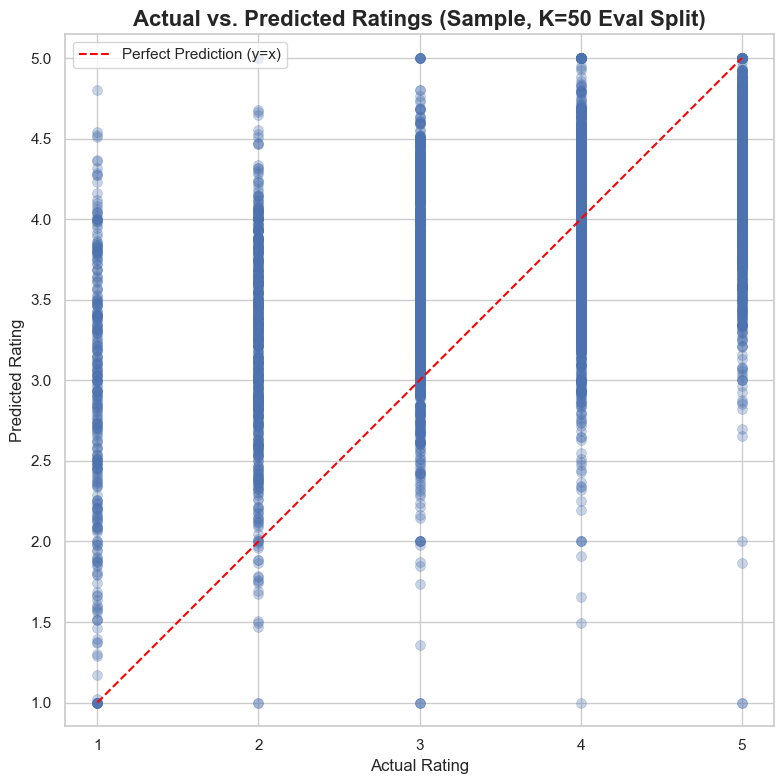

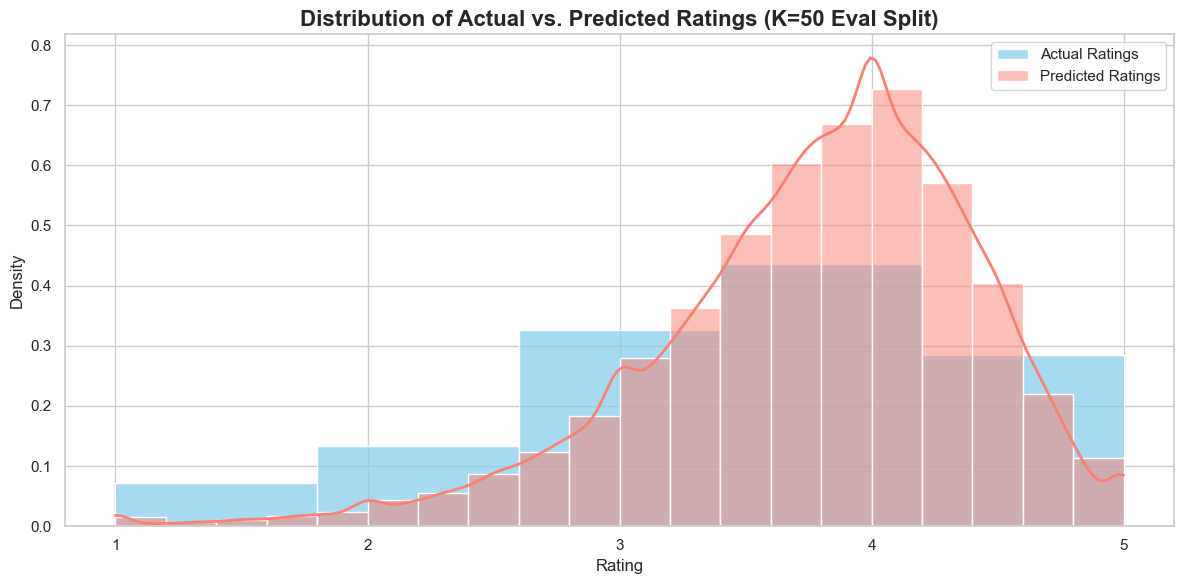

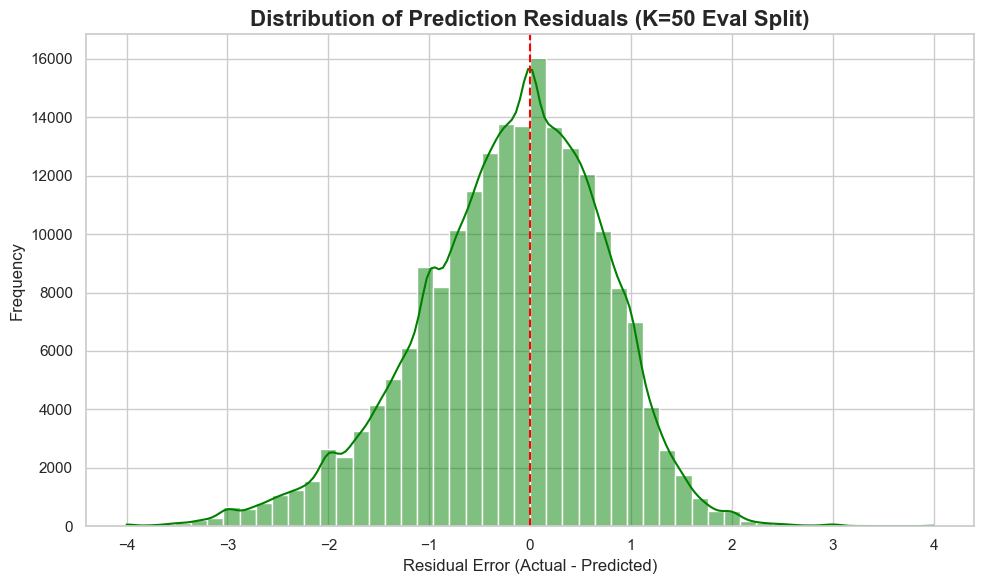


Residual Statistics (K=50 Eval Split):
count    200042.000000
mean         -0.190256
std           0.923146
min          -4.000000
25%          -0.753247
50%          -0.106244
75%           0.458313
max           4.000000
Name: Residual, dtype: float64

--- Visualizing Item-to-Item Similarity (using Final Model K=50) ---

Finding movies similar to: 'Toy Story (1995)'

Found 10 potential neighbors:
 - 1. Toy Story 2 (1999) (Similarity: 0.6331)
 - 2. Groundhog Day (1993) (Similarity: 0.6108)
 - 3. Aladdin (1992) (Similarity: 0.6058)
 - 4. Bug's Life, A (1998) (Similarity: 0.5794)
 - 5. Back to the Future (1985) (Similarity: 0.5701)
 - 6. Babe (1995) (Similarity: 0.5636)
 - 7. Star Wars: Episode V - The Empire Strikes Back (1980) (Similarity: 0.5529)
 - 8. Men in Black (1997) (Similarity: 0.5524)
 - 9. Forrest Gump (1994) (Similarity: 0.5510)
 - 10. Matrix, The (1999) (Similarity: 0.5503)


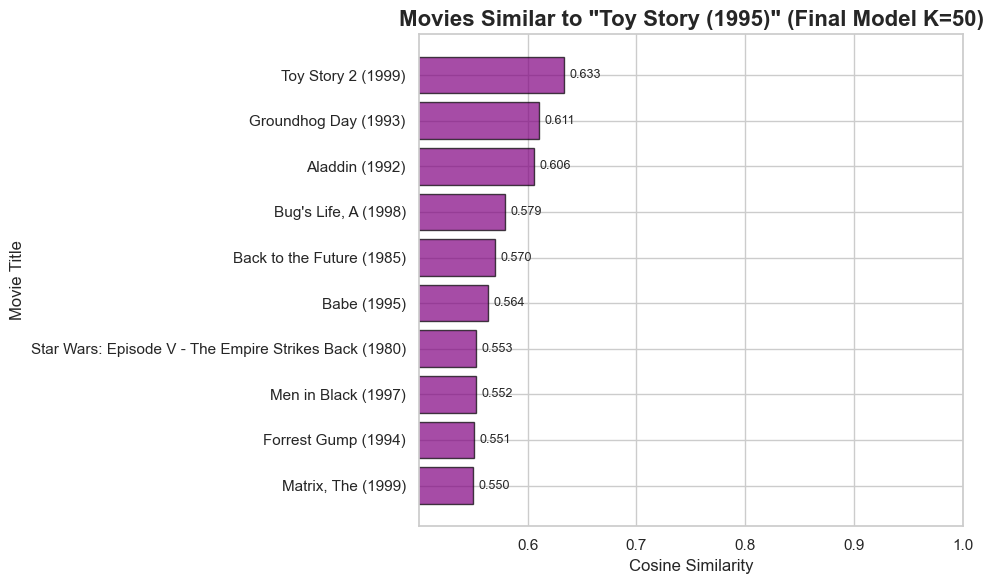


Finding movies similar to: 'Matrix, The (1999)'

Found 10 potential neighbors:
 - 1. Terminator 2: Judgment Day (1991) (Similarity: 0.7455)
 - 2. Total Recall (1990) (Similarity: 0.7033)
 - 3. Star Wars: Episode V - The Empire Strikes Back (1980) (Similarity: 0.6895)
 - 4. Men in Black (1997) (Similarity: 0.6848)
 - 5. Star Wars: Episode IV - A New Hope (1977) (Similarity: 0.6804)
 - 6. Jurassic Park (1993) (Similarity: 0.6784)
 - 7. Terminator, The (1984) (Similarity: 0.6727)
 - 8. Star Wars: Episode VI - Return of the Jedi (1983) (Similarity: 0.6568)
 - 9. Fugitive, The (1993) (Similarity: 0.6520)
 - 10. Fifth Element, The (1997) (Similarity: 0.6450)


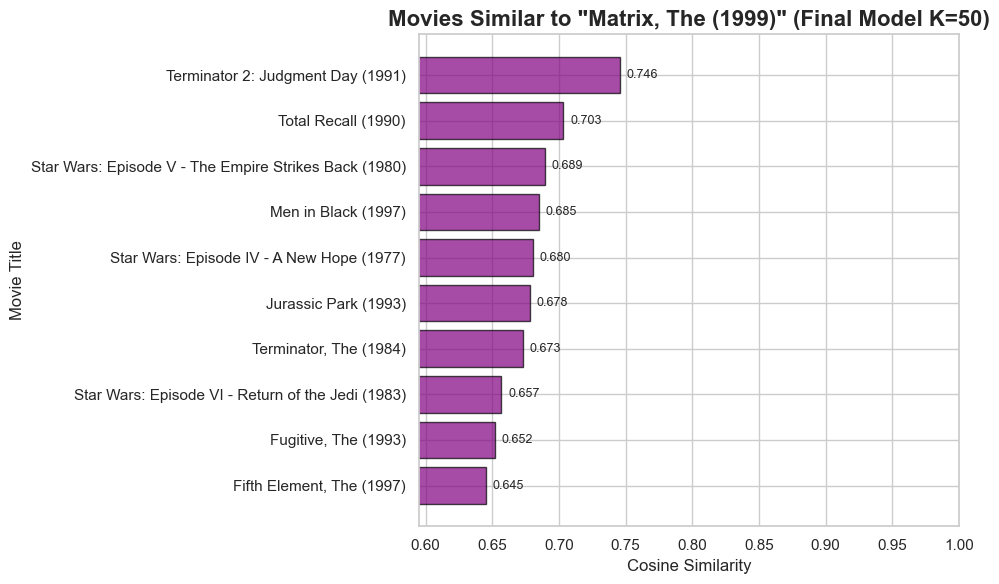


--- Visualizing User Recommendations (using Final Model K=50) ---


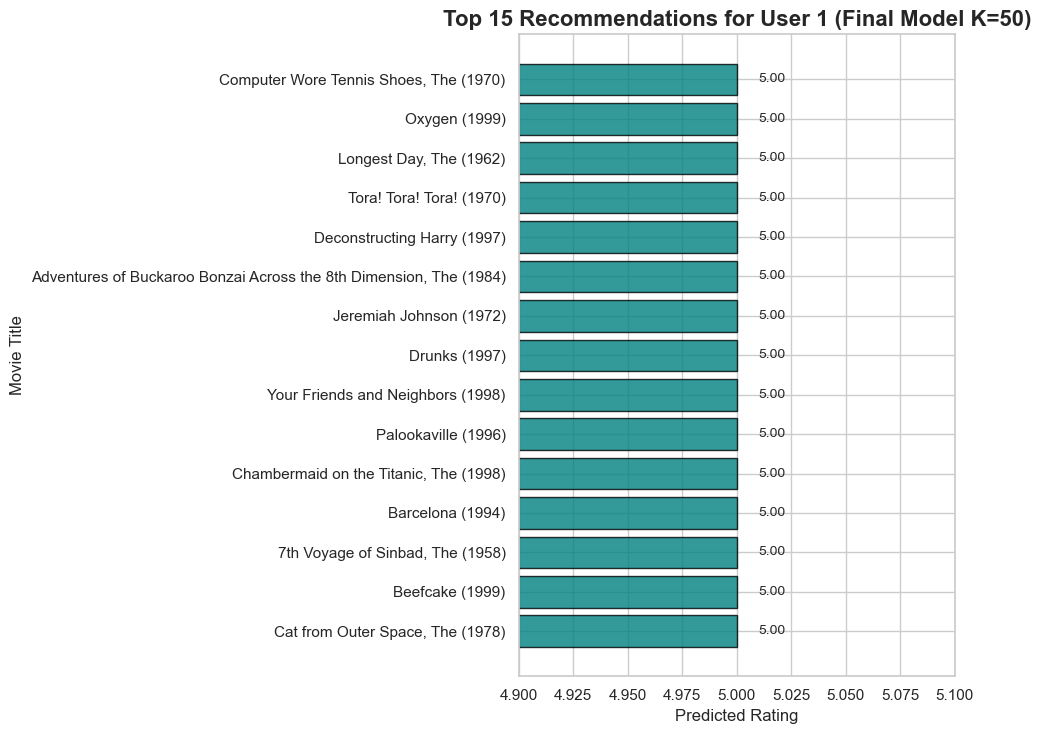

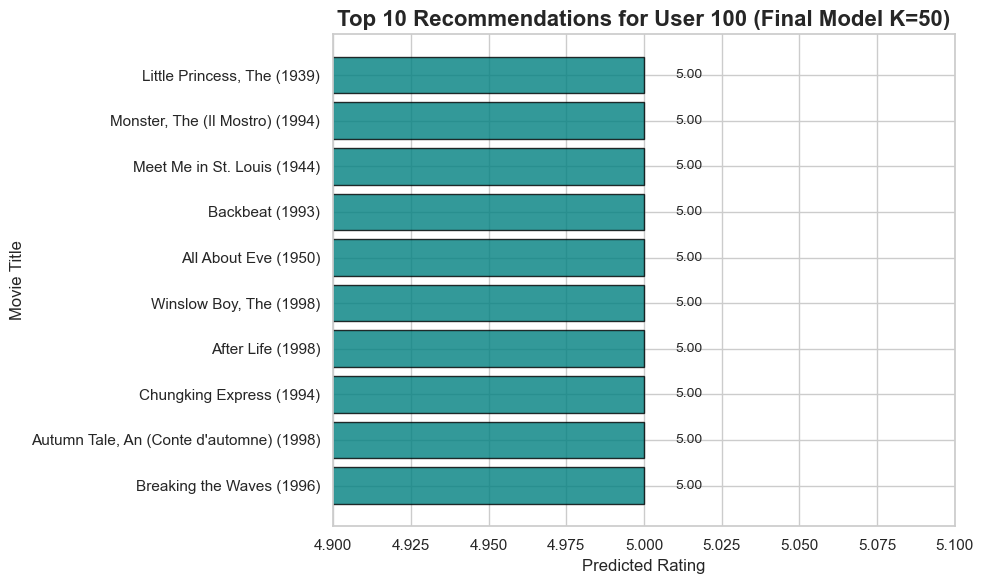

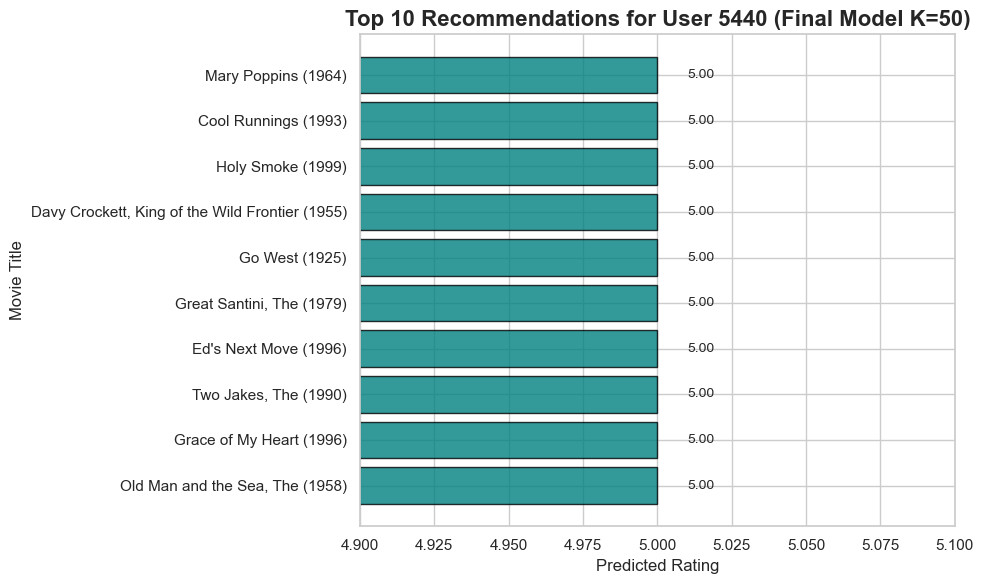

 Final Model: Item-Based KNN (Tuned K=50)
 Expected Performance (from CV): Avg RMSE=0.9406, Avg MAE=0.7264


In [32]:
"""
Part 8: Results Visualization
"""

sns.set_theme(style="whitegrid") # Use seaborn themes for nicer plots

# ============================================================
# == 1. Prediction Accuracy Visualization (from Single Split Eval in 6.5) ==
# ============================================================
print(f"\n--- Visualizing Prediction Accuracy (based on single split eval, K={best_k}) ---")
print(f"Note: Expected performance from CV (K={best_k}): Avg RMSE={best_rmse:.4f}, Avg MAE={best_mae:.4f}")
# Use rmse_eval, mae_eval if they exist from Step 6.5 for direct comparison
if 'rmse_eval' in globals() and 'mae_eval' in globals():
     print(f"Actual performance on this split: RMSE={rmse_eval:.4f}, MAE={mae_eval:.4f}")

# 1a. Scatter Plot
plt.figure(figsize=(8, 8))
sample_size = 5000
test_sample = test_ratings.sample(n=min(sample_size, len(test_ratings)), random_state=42)
sns.scatterplot(x='Rating', y='Prediction', data=test_sample, alpha=0.3, s=50, edgecolor=None)
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect Prediction (y=x)')
plt.title(f'Actual vs. Predicted Ratings (Sample, K={best_k} Eval Split)', fontsize=16, fontweight='bold')
plt.xlabel('Actual Rating', fontsize=12)
plt.ylabel('Predicted Rating', fontsize=12)
plt.xticks(range(1, 6)); plt.yticks(np.arange(1, 5.5, 0.5))
plt.legend(); plt.axis('equal'); plt.grid(True); plt.tight_layout()
plt.show()

# 1b. Distribution Comparison
plt.figure(figsize=(12, 6))
sns.histplot(test_ratings['Rating'], bins=5, kde=False, color='skyblue', label='Actual Ratings', stat='density')
sns.histplot(test_ratings['Prediction'], bins=20, kde=True, color='salmon', label='Predicted Ratings', stat='density', line_kws={'lw': 2})
plt.title(f'Distribution of Actual vs. Predicted Ratings (K={best_k} Eval Split)', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12); plt.ylabel('Density', fontsize=12)
plt.xticks(range(1, 6)); plt.legend(); plt.tight_layout()
plt.show()

# 1c. Residual Plot
if 'Residual' not in test_ratings.columns:
     test_ratings['Residual'] = test_ratings['Rating'] - test_ratings['Prediction']
plt.figure(figsize=(10, 6))
sns.histplot(test_ratings['Residual'], bins=50, kde=True, color='green')
plt.title(f'Distribution of Prediction Residuals (K={best_k} Eval Split)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error (Actual - Predicted)', fontsize=12); plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='--'); plt.grid(True); plt.tight_layout()
plt.show()
print(f"\nResidual Statistics (K={best_k} Eval Split):\n{test_ratings['Residual'].describe()}")


# ============================================================
# == 2. Item-to-Item Similarity Visualization (using Final K=50 Model) ==
# ============================================================
print(f"\n--- Visualizing Item-to-Item Similarity (using Final Model K={best_k}) ---")
# Use the find_similar_movies function defined in Part 4, passing the FINAL model and matrix
K_item_similarity_vis = 10 # Show top 10 similar items

def plot_similar_movies_final(similar_df, source_title):
    if similar_df is None or similar_df.empty: print(f"No similar movies data to plot for '{source_title}'."); return
    similar_df_sorted = similar_df.sort_values('Similarity', ascending=True)
    plt.figure(figsize=(10, max(6, len(similar_df_sorted) * 0.5)))
    bars = plt.barh(similar_df_sorted['Title'], similar_df_sorted['Similarity'], color='purple', alpha=0.7, edgecolor='black')
    plt.xlabel('Cosine Similarity', fontsize=12); plt.ylabel('Movie Title', fontsize=12)
    plt.title(f'Movies Similar to "{source_title}" (Final Model K={best_k})', fontsize=16, fontweight='bold')
    plt.xlim(max(0, similar_df_sorted['Similarity'].min() - 0.05) , 1.0)
    for bar in bars: plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2., f'{bar.get_width():.3f}', va='center', ha='left', fontsize=9)
    plt.tight_layout(); plt.show()

# --- Plot examples using the final model ---
example_movie_1 = 'Toy Story (1995)'
similar_movies_final_1 = find_similar_movies(example_movie_1, model_knn_final, movie_user_matrix_sparse_ALL, K_item_similarity_vis)
plot_similar_movies_final(similar_movies_final_1, example_movie_1)

example_movie_2 = 'Matrix, The (1999)'
similar_movies_final_2 = find_similar_movies(example_movie_2, model_knn_final, movie_user_matrix_sparse_ALL, K_item_similarity_vis)
plot_similar_movies_final(similar_movies_final_2, example_movie_2)


# ============================================================
# == 3. User Recommendation Visualization (using Final K=50 Model Recs) ==
# ============================================================
print(f"\n--- Visualizing User Recommendations (using Final Model K={best_k}) ---")

def plot_user_recs(recs_df, user_id, num_recs_display):
    if recs_df is None or recs_df.empty: print(f"\nNo recommendations data available to plot for User {user_id}."); return
    if not pd.api.types.is_numeric_dtype(recs_df['PredictedRating']):
         recs_df['PredictedRating'] = pd.to_numeric(recs_df['PredictedRating'], errors='coerce')
         recs_df.dropna(subset=['PredictedRating'], inplace=True)
    recs_df_sorted = recs_df.head(num_recs_display).sort_values('PredictedRating', ascending=True)
    plt.figure(figsize=(10, max(6, len(recs_df_sorted) * 0.5)))
    bars_user = plt.barh(recs_df_sorted['Title'], recs_df_sorted['PredictedRating'], color='teal', alpha=0.8, edgecolor='black')
    plt.xlabel('Predicted Rating', fontsize=12); plt.ylabel('Movie Title', fontsize=12)
    plt.title(f'Top {len(recs_df_sorted)} Recommendations for User {user_id} (Final Model K={best_k})', fontsize=16, fontweight='bold')
    if not recs_df_sorted.empty: plt.xlim(max(3.0, recs_df_sorted['PredictedRating'].min() - 0.1) , 5.1)
    else: plt.xlim(3.0, 5.1)
    for bar in bars_user: plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2., f'{bar.get_width():.2f}', va='center', ha='left', fontsize=10)
    plt.tight_layout(); plt.show()

# Plot recommendations generated in Part 7 (Finalized)
if 'user1_final_recommendations' in globals(): plot_user_recs(user1_final_recommendations, 1, 15)
if 'user100_final_recommendations' in globals(): plot_user_recs(user100_final_recommendations, 100, 10)
if 'user5440_final_recommendations' in globals(): plot_user_recs(user5440_final_recommendations, 5440, 10)

print(f" Final Model: Item-Based KNN (Tuned K={best_k})")
print(f" Expected Performance (from CV): Avg RMSE={best_rmse:.4f}, Avg MAE={best_mae:.4f}")

1.  **Prediction Accuracy Plots (Based on Single Split Eval, K=50):**
    *   **Actual vs. Predicted Scatter Plot:** Visually confirms the general prediction behavior. Points cluster vertically along actual ratings, indicating the model often predicts similar values regardless of the true rating, especially noticeable for actual ratings 1 and 5. The spread shows the typical error range. Most predictions fall between ~2.5 and ~4.5, rarely predicting the extremes (1 or 5) unless neighbor ratings strongly dictate it. This aligns with the RMSE value near 1.0.
    *   **Distribution Plot:** Clearly contrasts the discrete distribution of actual ratings (peaks at 3, 4, 5) with the smoother, more centrally peaked distribution of predicted ratings (peak around 3.8-4.0). This visually demonstrates the averaging effect of the KNN, which tends to regress towards the mean and rarely predicts extreme ratings.
    *   **Residual Plot:** Shows the distribution of errors (Actual - Predicted). It's roughly bell-shaped and centered slightly below zero (mean residual ≈ -0.19), suggesting a very slight tendency for the model to over-predict ratings on average in this specific test split. The spread confirms that most errors fall within +/- 1.5 rating points, but occasional larger errors exist (tails extending to -4 and +3).

2.  **Item-to-Item Similarity Plots (Based on Final Model, K=50):**
    *   These plots demonstrate the model's ability to identify semantically similar movies based on shared user rating patterns, using the final model trained on all data.
    *   **Toy Story (1995):** Correctly identifies 'Toy Story 2' as most similar, followed by other popular animated ('Aladdin', 'Bug's Life') and highly-rated family-friendly or classic comedy/adventure films ('Groundhog Day', 'Back to the Future', 'Babe'). Similarity scores range from ~0.55 to ~0.63.
    *   **Matrix, The (1999):** Correctly identifies similar high-profile Sci-Fi/Action films like 'Terminator 2', 'Total Recall', 'Star Wars' sequels, 'Men in Black', 'Fifth Element'. Similarity scores are generally higher here (0.64 to 0.75), possibly indicating a more distinct rating pattern for this genre cluster.
    *   **Overall:** The plots validate that the cosine similarity calculated by the KNN model on the user-item data effectively captures meaningful relationships between movies.

3.  **User Recommendation Plots (Based on Final Model, K=50):**
    *   These bar charts visualize the output of the `recommend_for_user_final` function.
    *   They clearly display the top N recommended movie titles for each example user, ordered by the predicted rating calculated by the final model.
    *   The x-axis (Predicted Rating) often shows values clustered near the top (e.g., 4.9-5.0), confirming the observation from Part 7 that the top predictions tend to be high with this KNN approach. While the absolute values might be compressed at the top end, the relative ranking provides the actionable recommendation list. The specific titles recommended differ clearly between users, demonstrating personalization based on their rating history.

**Overall Project Conclusion:** The project successfully implemented an item-based K-Nearest Neighbors collaborative filtering system. EDA revealed key data characteristics. Cross-validation was used effectively to tune the number of neighbors (K=50) for optimal predictive accuracy, achieving an average RMSE of approximately 0.94. The final model, trained on all data with the tuned K, generates plausible item-item similarities and personalized user recommendations. Visualizations effectively illustrate model performance and output. The achieved RMSE/MAE are typical for this algorithm on this dataset, indicating a functional baseline recommender system.